In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dataclasses import dataclass, replace
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

# Visual style & palette constants
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor']   = '#333333'
plt.rcParams['axes.linewidth']   = 0.8
plt.rcParams['grid.color']       = '#cccccc'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.5

C_OIL = '#4a2c1b'
C_IPR = '#1f77b4'   # deep blue
C_VLP = '#d62728'   # crimson
C_OP  = '#2ca02c'   # forest green
C_GAS = '#ff7f0e'   # amber
C_AOF = '#9467bd'   # purple
C_FB  = '#8c564b'   # brown
C_WC  = '#17becf'   # cyan/teal

G = 32.174  # ft/s^2, gravitational acceleration


In [2]:
# WELL TYPE SELECTOR  ---  run this cell to configure your well.

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, PillowWriter
import os, io, tempfile, base64

# Global configuration
WELL_CONFIG = dict(well_type='Vertical', angle_deg=90.0, survey=None)

# ── Standard API 5CT Tubing Catalogues (by well type) ─────────────
# Each entry: { 'label': nominal_label, 'OD_in': OD, 'ID_in': ID,
#               'weight_lbft': weight, 'default': True/False }
# The entry marked default=True is used when the user doesn't specify.
#
# Reference: API Specification 5CT; industry best-practice selection
# guidelines for vertical, horizontal, directional, and ERD wells.

TUBING_CATALOG = {
    # ----------- VERTICAL wells -----------
    # Conventional choice: 2-7/8" to 3-1/2" for moderate-rate oil wells.
    # Default: 2-7/8" (6.5 lb/ft, EUE) — workhorse of onshore verticals,
    # good balance of friction and liquid-loading prevention.
    'Vertical': [
        {'label': '1.900" (1.610 in ID)', 'OD_in': 1.900, 'ID_in': 1.610, 'weight_lbft': 2.75, 'default': False},
        {'label': '2-3/8" (1.995 in ID)', 'OD_in': 2.375, 'ID_in': 1.995, 'weight_lbft': 4.60, 'default': False},
        {'label': '2-7/8" (2.441 in ID)', 'OD_in': 2.875, 'ID_in': 2.441, 'weight_lbft': 6.50, 'default': True},
        {'label': '3-1/2" (2.992 in ID)', 'OD_in': 3.500, 'ID_in': 2.992, 'weight_lbft': 9.30, 'default': False},
        {'label': '4-1/2" (3.958 in ID)', 'OD_in': 4.500, 'ID_in': 3.958, 'weight_lbft': 12.60, 'default': False},
    ],
    # ----------- HORIZONTAL wells -----------
    # Horizontals favour larger tubing to minimise frictional pressure
    # drop along the long lateral. 3-1/2" or 4-1/2" are common.
    # Default: 3-1/2" (9.3 lb/ft) — most-used in unconventional laterals.
    'Horizontal': [
        {'label': '2-3/8" (1.995 in ID)', 'OD_in': 2.375, 'ID_in': 1.995, 'weight_lbft': 4.60, 'default': False},
        {'label': '2-7/8" (2.441 in ID)', 'OD_in': 2.875, 'ID_in': 2.441, 'weight_lbft': 6.50, 'default': False},
        {'label': '3-1/2" (2.992 in ID)', 'OD_in': 3.500, 'ID_in': 2.992, 'weight_lbft': 9.30, 'default': True},
        {'label': '4-1/2" (3.958 in ID)', 'OD_in': 4.500, 'ID_in': 3.958, 'weight_lbft': 12.60, 'default': False},
        {'label': '4-1/2" (4.000 in ID)', 'OD_in': 4.500, 'ID_in': 4.000, 'weight_lbft': 11.60, 'default': False},
    ],
    # ----------- DIRECTIONAL wells -----------
    # Directional (deviated / S-shape / J-shape) wells see higher
    # drag & torque.  2-7/8" to 3-1/2" most common; default 2-7/8".
    'Directional': [
        {'label': '2-3/8" (1.995 in ID)', 'OD_in': 2.375, 'ID_in': 1.995, 'weight_lbft': 4.60, 'default': False},
        {'label': '2-7/8" (2.441 in ID)', 'OD_in': 2.875, 'ID_in': 2.441, 'weight_lbft': 6.50, 'default': True},
        {'label': '3-1/2" (2.992 in ID)', 'OD_in': 3.500, 'ID_in': 2.992, 'weight_lbft': 9.30, 'default': False},
        {'label': '4-1/2" (3.958 in ID)', 'OD_in': 4.500, 'ID_in': 3.958, 'weight_lbft': 12.60, 'default': False},
    ],
    # ----------- CUSTOM trajectory -----------
    # Same catalogue as Directional; user presumably knows their well.
    'Custom': [
        {'label': '2-3/8" (1.995 in ID)', 'OD_in': 2.375, 'ID_in': 1.995, 'weight_lbft': 4.60, 'default': False},
        {'label': '2-7/8" (2.441 in ID)', 'OD_in': 2.875, 'ID_in': 2.441, 'weight_lbft': 6.50, 'default': True},
        {'label': '3-1/2" (2.992 in ID)', 'OD_in': 3.500, 'ID_in': 2.992, 'weight_lbft': 9.30, 'default': False},
        {'label': '4-1/2" (3.958 in ID)', 'OD_in': 4.500, 'ID_in': 3.958, 'weight_lbft': 12.60, 'default': False},
    ],
}

def get_default_tubing(well_type='Vertical'):
    """Return the default tubing entry for a well type."""
    cat = TUBING_CATALOG.get(well_type, TUBING_CATALOG['Vertical'])
    for t in cat:
        if t.get('default'):
            return t
    return cat[0]

def get_tubing_sensitivity_list(well_type='Vertical'):
    """Return {label: ID_in} dict for all tubing sizes for a well type."""
    cat = TUBING_CATALOG.get(well_type, TUBING_CATALOG['Vertical'])
    return {t['label']: t['ID_in'] for t in cat}


def _min_curve(md, inc, azi):
    md = np.asarray(md,float); inc = np.asarray(inc,float); azi = np.asarray(azi,float)
    n = len(md); tvd=np.zeros(n); north=np.zeros(n); east=np.zeros(n)
    for i in range(1, n):
        dmd=md[i]-md[i-1]; a1,a2=np.radians(inc[i-1]),np.radians(inc[i])
        f1,f2=np.radians(azi[i-1]),np.radians(azi[i])
        dl=np.arccos(np.clip(np.cos(a2-a1)-np.sin(a1)*np.sin(a2)*(1-np.cos(f2-f1)),-1,1))
        rf=(2/dl*np.tan(dl/2)) if dl>1e-9 else 1.0
        tvd[i]=tvd[i-1]+dmd/2*(np.cos(a1)+np.cos(a2))*rf
        north[i]=north[i-1]+dmd/2*(np.sin(a1)*np.cos(f1)+np.sin(a2)*np.cos(f2))*rf
        east[i]=east[i-1]+dmd/2*(np.sin(a1)*np.sin(f1)+np.sin(a2)*np.sin(f2))*rf
    return tvd, north, east

def build_survey_df(md, inc, azi, unit='ft'):
    md=np.asarray(md,float); inc=np.asarray(inc,float); azi=np.asarray(azi,float)
    if unit.lower() in ('m','meter','metre','meters','metres'): md=md*3.28084
    tvd, north, east = _min_curve(md, inc, azi)
    return pd.DataFrame({'MD_ft':md,'TVD_ft':tvd,'INC_survey_deg':inc,
                         'INC_code_deg':90.0-inc,'AZI_deg':azi,'North_ft':north,'East_ft':east})

def plot_survey_with_3d_gif(sv, out_widget=None):
    import contextlib
    ctx = out_widget if out_widget is not None else contextlib.nullcontext()
    with ctx:
        clear_output(wait=True)
        # 2-D views
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        ax1.plot(sv.East_ft, sv.North_ft, 'b.-', lw=1.5, ms=3)
        ax1.set(xlabel='East (ft)', ylabel='North (ft)', title='Plan View (Top-down)')
        ax1.set_aspect('equal', 'box'); ax1.grid(True, alpha=0.3)
        dep = np.hypot(sv.East_ft, sv.North_ft)
        ax2.plot(dep, -sv.TVD_ft, 'b.-', lw=1.5, ms=3)
        ax2.set(xlabel='Horizontal Departure (ft)', ylabel='TVD (ft)', title='Vertical Section')
        ax2.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()
        # 3-D rotating GIF  -- 72 frames x 5deg = 360deg, 6 fps => ~12s slow loop
        try:
            fig3d = plt.figure(figsize=(5.5, 4.5), dpi=80)
            ax3d = fig3d.add_subplot(111, projection='3d')
            ax3d.plot(sv.East_ft, sv.North_ft, -sv.TVD_ft, color='#1f77b4', lw=2.5, label='Trajectory')
            ax3d.scatter([sv.East_ft.iloc[0]],[sv.North_ft.iloc[0]],[-sv.TVD_ft.iloc[0]],
                         color='green', s=60, zorder=5, label='Wellhead')
            ax3d.scatter([sv.East_ft.iloc[-1]],[sv.North_ft.iloc[-1]],[-sv.TVD_ft.iloc[-1]],
                         color='red', s=60, zorder=5, label='TD')
            ax3d.set_xlabel('East (ft)', fontsize=8.5)
            ax3d.set_ylabel('North (ft)', fontsize=8.5)
            ax3d.set_zlabel('Depth (ft)', fontsize=8.5)
            ax3d.set_title('3D Well Trajectory (Rotating View)', fontsize=10.5, fontweight='bold')
            ax3d.legend(loc='upper right', fontsize=8)
            frames = range(0, 360, 5)
            def _upd(f): ax3d.view_init(elev=20, azim=f); return ax3d,
            anim = FuncAnimation(fig3d, _upd, frames=frames, interval=167)
            with tempfile.NamedTemporaryFile(suffix='.gif', delete=False) as tmp:
                anim.save(tmp.name, writer=PillowWriter(fps=6))
                tmp_path = tmp.name
            plt.close(fig3d)
            with open(tmp_path, 'rb') as f:
                gif_b64 = base64.b64encode(f.read()).decode()
            os.remove(tmp_path)
            display(HTML(
                '<div style="margin-top:10px">'
                '<b style="font-size:13px;color:#333">3D Trajectory Animation:</b><br/>'
                '<img src="data:image/gif;base64,' + gif_b64 + '" '
                'style="border:1px solid #ddd;border-radius:6px;margin-top:5px;'
                'max-width:480px;box-shadow:0 2px 6px rgba(0,0,0,.1)"/></div>'
            ))
        except Exception as e:
            print(f'Note: 3D GIF could not be generated: {e}')

_S    = {'description_width': '130px'}
_S_short = {'description_width': '50px'}
_S_col   = {'description_width': '70px'}
_W160 = widgets.Layout(width='165px')
_W240 = widgets.Layout(width='245px')
_W300 = widgets.Layout(width='305px')

wt_dd      = widgets.Dropdown(options=['Vertical','Horizontal','Directional','Custom'],
                 value='Vertical', description='Well Type:', style=_S, layout=_W300)
status_lbl = widgets.HTML('<span style="color:green;font-weight:bold">✔  Vertical  —  angle = 90°</span>')
out_main   = widgets.Output()

# DIRECTIONAL
dir_file  = widgets.FileUpload(accept='.xlsx,.xls,.csv', multiple=False,
               description='📂 Select File', style=_S, layout=_W300)
dir_sheet = widgets.Dropdown(description='Sheet / Table:', options=[], style=_S, layout=_W300, disabled=True)
dir_unit  = widgets.Dropdown(options=['ft','m'], value='ft', description='Depth unit:', style=_S, layout=_W300)
dir_md_c  = widgets.Dropdown(description='MD col:',  options=[], style=_S_col, layout=widgets.Layout(width='220px'), disabled=True)
dir_inc_c = widgets.Dropdown(description='INC col:', options=[], style=_S_col, layout=widgets.Layout(width='220px'), disabled=True)
dir_azi_c = widgets.Dropdown(description='AZI col:', options=[], style=_S_col, layout=widgets.Layout(width='220px'), disabled=True)
dir_load  = widgets.Button(description='⬆  Load & Compute TVD',
               button_style='primary', layout=widgets.Layout(width='220px'), disabled=True)
dir_out   = widgets.Output()
_cached_excel = None
_cached_csv   = None

def _guess_col(opts, patterns):
    for o in opts:
        ol = str(o).strip().lower()
        for p in patterns:
            if ol == p or p in ol: return o
    return opts[0] if opts else None

def _update_cols(cols):
    cs = [str(c) for c in cols]
    if not cs: return
    dir_md_c.options  = cs; dir_md_c.disabled  = False
    dir_inc_c.options = cs; dir_inc_c.disabled = False
    g = _guess_col(cs, ['md','measured','depth']);     dir_md_c.value  = g if g else cs[0]
    g = _guess_col(cs, ['inc','incl','inclination']);  dir_inc_c.value = g if g else cs[0]
    ao = ['(None / 0°)'] + cs
    dir_azi_c.options = ao; dir_azi_c.disabled = False
    g = _guess_col(cs, ['azi','azim','azimuth','dir']); dir_azi_c.value = g if g else '(None / 0°)'

def _on_sheet(change):
    if _cached_excel and change['new']:
        try:   _update_cols(list(_cached_excel.parse(change['new'], nrows=3).columns))
        except Exception as e:
            with dir_out: print(f'⚠  {e}')

dir_sheet.observe(_on_sheet, names='value')

def _on_upload(change):
    global _cached_excel, _cached_csv
    with dir_out:
        clear_output()
        val = dir_file.value
        if not val: return
        try:
            if isinstance(val, dict):
                fname = list(val.keys())[0]; content = val[fname]['content']
            else:
                fname = val[0]['name'];       content = val[0]['content']
            fb  = content if isinstance(content, bytes) else content.tobytes()
            ext = os.path.splitext(fname)[1].lower()
            if ext in ('.xlsx','.xls','.xlsm','.xlsb'):
                _cached_excel = pd.ExcelFile(io.BytesIO(fb)); _cached_csv = None
                sn = _cached_excel.sheet_names
                dir_sheet.options = sn; dir_sheet.disabled = False
                if sn:
                    dir_sheet.value = sn[0]
                    _update_cols(list(_cached_excel.parse(sn[0], nrows=3).columns))
                print(f'✔  {repr(fname)} loaded — {len(sn)} sheet(s). Select sheet & columns, then click Load.')
            elif ext == '.csv':
                _cached_excel = None; _cached_csv = pd.read_csv(io.BytesIO(fb))
                dir_sheet.options = ['(CSV — no sheets)']; dir_sheet.disabled = True
                _update_cols(list(_cached_csv.columns))
                print(f'✔  CSV {repr(fname)} loaded. Check columns and click Load.')
            else:
                print(f'⚠  Unsupported format: {ext}'); return
            dir_load.disabled = False
        except Exception as e:
            import traceback; print(f'✘  {e}'); traceback.print_exc()

dir_file.observe(_on_upload, names='value')

def _load_dir(btn):
    with dir_out:
        clear_output()
        if _cached_excel is None and _cached_csv is None:
            print('⚠  Upload a file first.'); return
        try:
            df = _cached_excel.parse(dir_sheet.value) if _cached_excel else _cached_csv
            mc, ic, ac = str(dir_md_c.value), str(dir_inc_c.value), str(dir_azi_c.value)
            miss = [c for c in [mc, ic] if c not in df.columns]
            if miss:
                print(f'⚠  Columns not found: {miss}\n   Available: {list(df.columns)}'); return
            md_a  = df[mc].values.astype(float)
            inc_a = df[ic].values.astype(float)
            azi_a = df[ac].values.astype(float) if (ac in df.columns and ac!='(None / 0°)') else np.zeros(len(md_a))
            sv = build_survey_df(md_a, inc_a, azi_a, unit=dir_unit.value)
            WELL_CONFIG.update(well_type='Directional', angle_deg=None, survey=sv)
            print(f'✔  Survey: {len(sv)} stations  |  MD 0→{sv.MD_ft.iloc[-1]:,.0f} ft  |  TVD 0→{sv.TVD_ft.iloc[-1]:,.0f} ft')
            print(f'   Max inclination: {sv.INC_survey_deg.max():.1f}°   (rendering plots, please wait…)')
            plot_survey_with_3d_gif(sv, out_widget=dir_out)
            status_lbl.value = (
                f'<span style="color:green;font-weight:bold">✔  Directional — '
                f'{len(sv)} stations | Max inc {sv.INC_survey_deg.max():.1f}° | '
                f'TVD {sv.TVD_ft.iloc[-1]:,.0f} ft</span>')
        except Exception as e:
            import traceback; print(f'✘  {e}'); traceback.print_exc()

dir_load.on_click(_load_dir)

dir_panel = widgets.VBox([
    widgets.HTML('<b style="font-size:14px">📂 Directional Survey — File Input</b>'),
    widgets.HTML('<span style="color:#555;font-size:12px">INC: 0° = vertical, 90° = horizontal</span>'),
    dir_file,
    widgets.HBox([dir_sheet, dir_unit]),
    widgets.HBox([dir_md_c, dir_inc_c, dir_azi_c]),
    dir_load, dir_out,
], layout=widgets.Layout(border='1px solid #ccc', padding='12px', margin='8px 0'))

# CUSTOM
_cst_rows = []

cst_unit = widgets.Dropdown(options=['ft','m'], value='ft', description='Depth unit:', style=_S, layout=_W300)
cst_md   = widgets.FloatText(value=0, description='MD:',    style=_S_short, layout=widgets.Layout(width='190px'))
cst_inc  = widgets.FloatText(value=0, description='INC°:', style=_S_short, layout=widgets.Layout(width='190px'))
cst_azi  = widgets.FloatText(value=0, description='AZI°:', style=_S_short, layout=widgets.Layout(width='190px'))
cst_add  = widgets.Button(description='➕ Add Station',      button_style='success', layout=_W160)
cst_del  = widgets.Button(description='🗑 Del Last',      button_style='warning', layout=_W160)
cst_clr  = widgets.Button(description='✖ Clear All',         button_style='danger',  layout=_W160)
cst_apl  = widgets.Button(description='✔  Apply & Preview',  button_style='primary',
               layout=widgets.Layout(width='210px'))
cst_tbl  = widgets.HTML('<i style="color:#888">No stations yet. Add ≥2 then click Apply & Preview.</i>')
cst_out  = widgets.Output()

def _cst_refresh_table():
    if not _cst_rows:
        cst_tbl.value = '<i style="color:#888">No stations yet. Add ≥2 then click Apply & Preview.</i>'; return
    h = ('<table border="1" style="border-collapse:collapse;font-size:12px;font-family:monospace;margin:4px 0">'
         '<tr style="background:#f0f0f0"><th style="padding:3px 10px">#</th>'
         '<th style="padding:3px 10px">MD</th><th style="padding:3px 10px">INC (°)</th>'
         '<th style="padding:3px 10px">AZI (°)</th></tr>')
    for j, r in enumerate(_cst_rows, 1):
        h += (f'<tr><td style="padding:3px 10px">{j}</td>'
              f'<td style="padding:3px 10px">{r["md"]:.1f}</td>'
              f'<td style="padding:3px 10px">{r["inc"]:.2f}</td>'
              f'<td style="padding:3px 10px">{r["azi"]:.2f}</td></tr>')
    cst_tbl.value = h + '</table>'

def _cst_add(btn):
    _cst_rows.append({'md': cst_md.value, 'inc': cst_inc.value, 'azi': cst_azi.value})
    _cst_rows.sort(key=lambda x: x['md'])
    _cst_refresh_table()   # only update table, no plot

def _cst_del(btn):
    if _cst_rows: _cst_rows.pop()
    _cst_refresh_table()

def _cst_clr(btn):
    _cst_rows.clear(); _cst_refresh_table()
    with cst_out: clear_output()

def _cst_apply(btn):
    with cst_out:
        if len(_cst_rows) < 2:
            clear_output(); print('⚠  Add at least 2 stations first.'); return
        md_a = np.array([r['md']  for r in _cst_rows])
        ic_a = np.array([r['inc'] for r in _cst_rows])
        az_a = np.array([r['azi'] for r in _cst_rows])
        sv = build_survey_df(md_a, ic_a, az_a, unit=cst_unit.value)
        WELL_CONFIG.update(well_type='Custom', angle_deg=None, survey=sv)
        status_lbl.value = (
            f'<span style="color:green;font-weight:bold">✔  Custom — '
            f'{len(sv)} stations | Max inc {sv.INC_survey_deg.max():.1f}° | '
            f'TVD {sv.TVD_ft.iloc[-1]:,.0f} ft</span>')
        print('✔  Trajectory applied — rendering plots, please wait…')
        plot_survey_with_3d_gif(sv, out_widget=cst_out)

cst_add.on_click(_cst_add); cst_del.on_click(_cst_del)
cst_clr.on_click(_cst_clr); cst_apl.on_click(_cst_apply)

cust_panel = widgets.VBox([
    widgets.HTML('<b style="font-size:14px">✏  Custom Well — Interactive Trajectory Builder</b>'),
    widgets.HTML('<span style="color:#555;font-size:12px">INC: 0°=vertical, 90°=horizontal | '
                 'Stations sorted by MD. Click <b>Apply & Preview</b> to compute + visualise.</span>'),
    cst_unit,
    widgets.HBox([cst_md, cst_inc, cst_azi]),
    widgets.HBox([cst_add, cst_del, cst_clr]),
    cst_tbl,
    cst_apl,
    cst_out,
], layout=widgets.Layout(border='1px solid #ccc', padding='12px', margin='8px 0'))

def _on_wt_change(change):
    wt = change['new']
    with out_main:
        clear_output(wait=True)
        if wt == 'Vertical':
            WELL_CONFIG.update(well_type='Vertical', angle_deg=90.0, survey=None)
            status_lbl.value = '<span style="color:green;font-weight:bold">✔  Vertical  —  angle = 90°</span>'
        elif wt == 'Horizontal':
            WELL_CONFIG.update(well_type='Horizontal', angle_deg=0.0, survey=None)
            status_lbl.value = '<span style="color:green;font-weight:bold">✔  Horizontal  —  angle = 0°</span>'
        elif wt == 'Directional':
            WELL_CONFIG.update(well_type='Directional', angle_deg=None, survey=None)
            status_lbl.value = '<span style="color:darkorange;font-weight:bold">⏳  Directional — load survey file below</span>'
            display(dir_panel)
        elif wt == 'Custom':
            WELL_CONFIG.update(well_type='Custom', angle_deg=None, survey=None)
            status_lbl.value = '<span style="color:darkorange;font-weight:bold">⏳  Custom — build trajectory below</span>'
            display(cust_panel)

wt_dd.observe(_on_wt_change, names='value')

display(widgets.VBox([
    widgets.HTML(
        '<h3 style="margin:6px 0;color:#333">⚙  Well Type Configuration</h3>'
        '<p style="color:#555;font-size:12px;margin:0 0 6px 0">'
        'Select a well type, configure the trajectory, then re-run the VLP cells below.</p>'),
    wt_dd, status_lbl, out_main,
]))


In [3]:
# Oil PVT  (Standing, 1947;  Vasquez & Beggs, 1980 for undersaturated co)

def oil_sg(API):
    """Stock-tank oil specific gravity from API gravity."""
    return 141.5 / (131.5 + API)

def standing_rs(P, gg, API, T):
    """Standing (1947) solution GOR, scf/STB. Valid for P <= Pb."""
    a = 0.0125 * API - 0.00091 * T
    return gg * ((P / 18.2 + 1.4) * 10 ** a) ** 1.2048

def standing_pb(Rsb, gg, API, T):
    """Standing (1947) bubble-point pressure, psia (inverse of standing_rs)."""
    a = 0.0125 * API - 0.00091 * T
    return 18.2 * ((Rsb / gg) ** (1 / 1.2048) * 10 ** (-a) - 1.4)

def standing_bo_sat(Rs, gg, go, T):
    """Standing (1947) saturated oil FVF, rb/STB."""
    F = Rs * (gg / go) ** 0.5 + 1.25 * T
    return 0.9759 + 0.00012 * F ** 1.2

def vasquez_beggs_co(P, Rsb, gg, API, T):
    """Vasquez & Beggs (1980) undersaturated oil isothermal compressibility, 1/psi."""
    return (-1433 + 5 * Rsb + 17.2 * T - 1180 * gg + 12.61 * API) / (1e5 * P)

def oil_pvt(P, gg, API, T, Pb, Rsb):
    """Return (Rs, Bo, rho_o[lbm/ft3]) at pressure P, honoring saturated/undersaturated regime."""
    go = oil_sg(API)
    if P < Pb:
        Rs = standing_rs(P, gg, API, T)
        Bo = standing_bo_sat(Rs, gg, go, T)
    else:
        Rs = Rsb
        Bob = standing_bo_sat(Rsb, gg, go, T)
        co = vasquez_beggs_co(P, Rsb, gg, API, T)
        Bo = Bob * np.exp(co * (Pb - P))
    rho_o = (350.17 * go + 0.0764 * Rs * gg) / (5.615 * Bo)   # lbm/ft3
    return Rs, Bo, rho_o

def beggs_robinson_muo(P, T, API, Rs, Pb):
    """Beggs & Robinson (1975) dead-oil and saturated live-oil viscosity, cp.
       Above Pb, corrected with the Beggs & Robinson undersaturated multiplier."""
    Z = 3.0324 - 0.02023 * API
    Y = 10 ** Z
    X = Y * T ** -1.163
    mu_od = 10 ** X - 1
    a = 10.715 * (Rs + 100) ** -0.515
    b = 5.44 * (Rs + 150) ** -0.338
    mu_ob = a * mu_od ** b
    if P > Pb:
        m = 2.6 * P ** 1.187 * np.exp(-11.513 - 8.98e-5 * P)
        return max(mu_ob * (P / Pb) ** m, 0.05)
    return max(mu_ob, 0.05)

def baker_swerdloff_ift(P, API, T):
    """Baker & Swerdloff (1956) dead-oil surface tension with Standing's live-oil
       (pressure) correction, dynes/cm."""
    s68  = 39.0 - 0.2571 * API
    s100 = 37.5 - 0.2571 * API
    Tc = np.clip(T, 68, 100)
    s_dead = s68 - (Tc - 68) * (s68 - s100) / 32
    corr = 1 - 0.024 * P ** 0.45
    return max(s_dead * corr, 1.0)

#  Gas PVT  (Sutton, 1985 pseudocriticals;  Dranchuk & Abou-Kassem, 1975 Z;
#                Lee, Gonzalez & Eakin, 1966 viscosity)

def gas_pseudocritical(gg):
    """Sutton (1985) pseudo-critical temperature (degR) and pressure (psia)."""
    Tpc = 169.2 + 349.5 * gg - 74.0 * gg ** 2
    Ppc = 756.8 - 131.0 * gg - 3.6 * gg ** 2
    return Tpc, Ppc

def _z_dak(Ppr, Tpr):
    """Dranchuk & Abou-Kassem (1975) real-gas Z-factor, solved implicitly."""
    A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11 = (0.3265,-1.0700,-0.5339,0.01569,-0.05165,
        0.5475,-0.7361,0.1844,0.1056,0.6134,0.7210)
    def resid(Z):
        rho_r = 0.27 * Ppr / (Z * Tpr)
        c1 = A1 + A2/Tpr + A3/Tpr**3 + A4/Tpr**4 + A5/Tpr**5
        c2 = A6 + A7/Tpr + A8/Tpr**2
        c3 = A9 * (A7/Tpr + A8/Tpr**2)
        rhs = (1 + c1*rho_r + c2*rho_r**2 - c3*rho_r**5 +
               A10*(1+A11*rho_r**2)*(rho_r**2/Tpr**3)*np.exp(-A11*rho_r**2))
        return Z - rhs
    try:
        return brentq(resid, 0.2, 3.0, xtol=1e-8, maxiter=200)
    except ValueError:
        return 0.9

def gas_z(P, T, gg):
    Tpc, Ppc = gas_pseudocritical(gg)
    return _z_dak(P / Ppc, (T + 460) / Tpc)

def gas_bg(P, T, Z):
    """Gas FVF, rcf/scf."""
    return 0.02827 * Z * (T + 460) / P

def gas_rho(P, T, Z, gg):
    """Gas density, lbm/ft3."""
    return 2.7 * gg * P / (Z * (T + 460))

def lee_gas_visc(P, T, Z, gg):
    """Lee, Gonzalez & Eakin (1966) gas viscosity, cp."""
    Ma = 28.97 * gg
    rho_g_gcc = gas_rho(P, T, Z, gg) / 62.4
    K = (9.4 + 0.02 * Ma) * (T + 460) ** 1.5 / (209 + 19 * Ma + (T + 460))
    X = 3.5 + 986 / (T + 460) + 0.01 * Ma
    Y = 2.4 - 0.2 * X
    return 1e-4 * K * np.exp(X * rho_g_gcc ** Y)

def water_pvt(T):
    """Simplified water FVF, density, viscosity."""
    Bw = 1.0
    rho_w = 62.4 * 1.07
    mu_w = max(1.0 - 0.012 * (T - 60), 0.30)
    return Bw, rho_w, mu_w

print("PVT package loaded.")


PVT package loaded.


(base case not yet defined — using demo values: API=35°, γg=0.75, T=180°F, GOR=600)


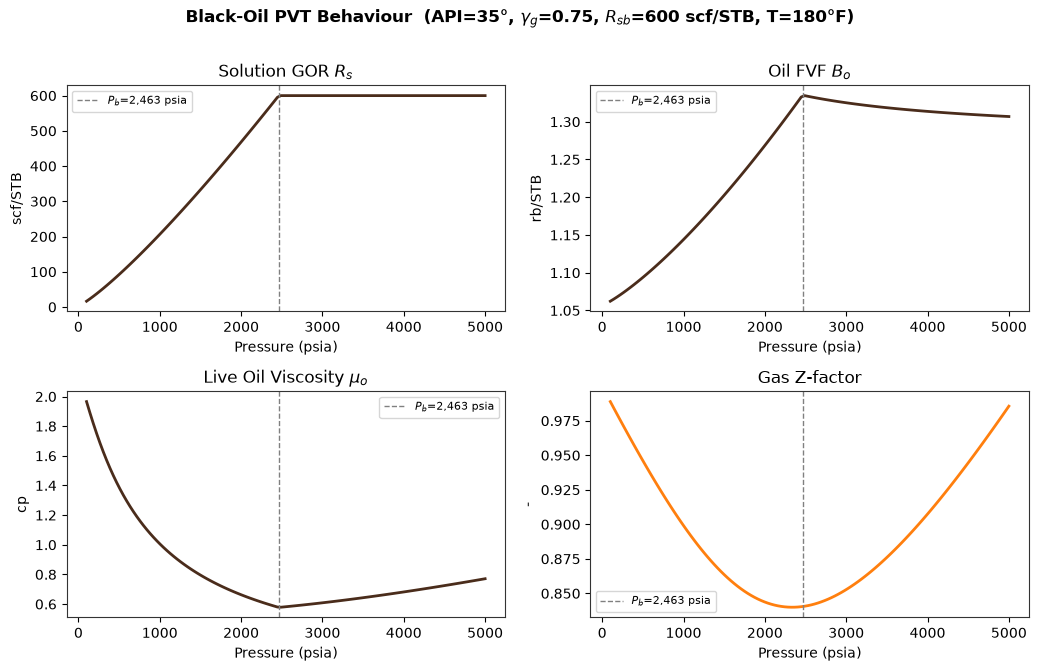

Bubble point pressure Pb = 2,463.2 psia
Round-trip check, Rs(Pb) = 600.0 (should equal Rsb = 600)


In [4]:
# --- PVT validation / visualization using the ACTIVE well-case fluid properties ---

try:
    API_chk = base.API
    gg_chk  = base.gg
    T_chk   = base.T_res
    GOR_chk = base.GOR
    print(f"Plotting PVT for YOUR fluid: API={API_chk}°, γg={gg_chk}, T={T_chk}°F, GOR={GOR_chk} scf/STB")
except NameError:
    API_chk, gg_chk, T_chk, GOR_chk = 35, 0.75, 180, 600
    print(f"(base case not yet defined — using demo values: API={API_chk}°, γg={gg_chk}, T={T_chk}°F, GOR={GOR_chk})")

Rsb_chk = GOR_chk
Pb_chk = standing_pb(Rsb_chk, gg_chk, API_chk, T_chk)
P_range = np.linspace(100, 5000, 120)

Rs_arr, Bo_arr, muo_arr, Z_arr, mug_arr = [], [], [], [], []
for P in P_range:
    Rs, Bo, _ = oil_pvt(P, gg_chk, API_chk, T_chk, Pb_chk, Rsb_chk)
    Rs_arr.append(Rs); Bo_arr.append(Bo)
    muo_arr.append(beggs_robinson_muo(P, T_chk, API_chk, Rs, Pb_chk))
    Z = gas_z(P, T_chk, gg_chk); Z_arr.append(Z)
    mug_arr.append(lee_gas_visc(P, T_chk, Z, gg_chk))

fig, axs = plt.subplots(2, 2, figsize=(10.5, 6.6))
for ax, y, title, ylab, c in zip(
    axs.flat,
    [Rs_arr, Bo_arr, muo_arr, Z_arr],
    ["Solution GOR $R_s$", "Oil FVF $B_o$", "Live Oil Viscosity $\\mu_o$", "Gas Z-factor"],
    ["scf/STB", "rb/STB", "cp", "-"],
    [C_OIL, C_OIL, C_OIL, C_GAS]):
    ax.plot(P_range, y, color=c, lw=2)
    ax.axvline(Pb_chk, color="gray", ls="--", lw=1, label=f"$P_b$={Pb_chk:,.0f} psia")
    ax.set_title(title); ax.set_xlabel("Pressure (psia)"); ax.set_ylabel(ylab)
    ax.legend(fontsize=8)
fig.suptitle(f"Black-Oil PVT Behaviour  (API={API_chk}°, $\\gamma_g$={gg_chk}, "
             f"$R_{{sb}}$={Rsb_chk} scf/STB, T={T_chk}°F)", y=1.01, fontweight="bold")
fig.tight_layout()
plt.show()

print(f"Bubble point pressure Pb = {Pb_chk:,.1f} psia")
print(f"Round-trip check, Rs(Pb) = {standing_rs(Pb_chk, gg_chk, API_chk, T_chk):.1f} "
      f"(should equal Rsb = {Rsb_chk})")


In [5]:
@dataclass
class WellCase:
    Pr: float        # psia, current average reservoir pressure
    T_res: float      # degF, bottomhole/reservoir temperature
    T_wh: float       # degF, wellhead flowing temperature
    API: float        # deg API
    gg: float         # gas specific gravity (air=1)
    GOR: float        # scf/STB, producing gas-oil ratio
    wc: float          # water cut, fraction
    depth: float       # ft, TVD to mid-perforations
    d_in: float        # in, tubing ID
    Pwh: float         # psia, flowing wellhead (tubing-head) pressure set by choke/separator
    q_test: float      # STB/d, total liquid rate at the reference well test
    Pwf_test: float    # psia, flowing BHP measured at the reference well test
    angle_deg: float = 90.0
    roughness_in: float = 0.0006   # in, absolute tubing roughness

# WELL, RESERVOIR & FLUID PARAMETERS — edit these or leave as None


# ── Reservoir ──
_Pr       = None    # psia   — average reservoir pressure          (default: 4200)
_T_res    = None    # °F     — reservoir / bottomhole temperature  (default: 180)
_T_wh     = None    # °F     — wellhead flowing temperature        (default: 120)

# ── Fluid ───
_API      = None    # °API   — oil gravity               (default: 35)
_gg       = None    # –      — gas specific gravity (air=1)   (default: 0.75)
_GOR      = None    # scf/STB — producing gas-oil rat     (default: 600)
_wc       = None    # fraction — water cut                    (default: 0.20)

# ── Well geometry ───
_depth    = None    # ft     — TVD to mid-perforations
#                   #   Vertical/Horizontal: default 8500 ft
#                   #   Directional/Custom:  auto-read from survey TVD
_d_in     = None    # in     — tubing ID (None = auto from well type)
_Pwh      = None    # psia   — flowing wellhead pressure        (default: 300)
_rough    = None    # in     — absolute tubing roughness     (default: 0.0006)

# ── Well test data ───
_q_test   = None    # STB/d  — total liquid rate at test      (default: 1300)
_Pwf_test = None    # psia   — flowing BHP at test      (default: 3400)

# ── DEFAULTS ENGINE 

_well_type  = WELL_CONFIG.get('well_type', 'Vertical')
_survey     = WELL_CONFIG.get('survey')          # DataFrame or None
_def_tubing = get_default_tubing(_well_type)

# ── Angle: None for survey-based wells; use a representative value
#    for the WellCase (vlp_pwf_of_q dispatches to vlp_traverse_survey
#    automatically when survey is present, so angle_deg is not used then).

_angle_raw = WELL_CONFIG.get('angle_deg')       
if _angle_raw is not None:
    _angle = float(_angle_raw)
elif _well_type == 'Horizontal':
    _angle = 0.0
else:
    _angle = 90.0    # placeholder — actual path comes from survey

# ── Depth: auto-read from survey TVD if available
if _depth is not None:
    depth = float(_depth)
elif _survey is not None and len(_survey) > 0:
    depth = float(_survey['TVD_ft'].iloc[-1])
    print(f"ℹ️  depth auto-read from survey TVD: {depth:,.0f} ft")
else:
    depth = 8500

# ── Resolve remaining None → defaults
Pr       = _Pr       if _Pr       is not None else 4200
T_res    = _T_res    if _T_res    is not None else 180
T_wh     = _T_wh     if _T_wh     is not None else 120
API      = _API      if _API      is not None else 35
gg       = _gg       if _gg       is not None else 0.75
GOR      = _GOR      if _GOR      is not None else 600
wc       = _wc       if _wc       is not None else 0.20
d_in     = _d_in     if _d_in     is not None else _def_tubing['ID_in']
Pwh      = _Pwh      if _Pwh      is not None else 300
rough    = _rough    if _rough    is not None else 0.0006
q_test   = _q_test   if _q_test   is not None else 1300
Pwf_test = _Pwf_test if _Pwf_test is not None else 3400

# ── Build the WellCase
base = WellCase(
    Pr=Pr, T_res=T_res, T_wh=T_wh, API=API, gg=gg, GOR=GOR, wc=wc,
    depth=depth, d_in=d_in, Pwh=Pwh, q_test=q_test, Pwf_test=Pwf_test,
    angle_deg=_angle, roughness_in=rough,
)

# ── Derive PVT anchors
Pb  = standing_pb(base.GOR, base.gg, base.API, base.T_res)
Rsb = base.GOR

# ── Find tubing label matching d_in
_tubing_label = "Custom"
for t in TUBING_CATALOG.get(_well_type, []):
    if abs(t['ID_in'] - d_in) < 0.01:
        _tubing_label = t['label']
        break

# ── Angle display string
_angle_display = (f"{base.angle_deg:.1f}" if _angle_raw is not None
                  else "survey-based (varies)")

# ── Depth source label
_depth_src = ("✏️ user" if _depth is not None
              else ("📐 from survey TVD" if _survey is not None else "🔧 default"))

# ── Summary table
_src = lambda v, user_v: "✏️ user" if user_v is not None else "🔧 default"

print(f"╔══════════════════════════════════════════════════════════════╗")
print(f"║  Well Type: {_well_type:<15s}  │  Default Tubing: {_def_tubing['label']:<22s}║")
print(f"╚══════════════════════════════════════════════════════════════╝\n")

_summary = pd.DataFrame({
    "Parameter": ["Reservoir pressure Pr", "Bubble-point pressure Pb (computed)",
                  "Reservoir temperature", "Wellhead temperature",
                  "Oil gravity (API)", "Gas gravity γg", "Producing GOR",
                  "Water cut", "Well depth (TVD)", f"Tubing ID ({_tubing_label})",
                  "Wellhead pressure", "Tubing roughness",
                  "Well test rate", "Well test Pwf", "Well angle (B&B convention)"],
    "Value": [f"{base.Pr:,.0f}", f"{Pb:,.0f}",
              f"{base.T_res:,.0f}", f"{base.T_wh:,.0f}",
              f"{base.API:.1f}", f"{base.gg:.3f}", f"{base.GOR:,.0f}",
              f"{base.wc:.2%}", f"{base.depth:,.0f}", f"{base.d_in:.3f}",
              f"{base.Pwh:,.0f}", f"{base.roughness_in:.4f}",
              f"{base.q_test:,.0f}", f"{base.Pwf_test:,.0f}", _angle_display],
    "Units": ["psia", "psia", "°F", "°F", "°API", "–", "scf/STB",
              "–", "ft", "in", "psia", "in", "STB/d", "psia", "deg"],
    "Source": [_src(Pr,_Pr), "computed", _src(T_res,_T_res), _src(T_wh,_T_wh),
               _src(API,_API), _src(gg,_gg), _src(GOR,_GOR),
               _src(wc,_wc), _depth_src,
               _src(d_in,_d_in) if _d_in is not None else f"🔧 {_well_type} default",
               _src(Pwh,_Pwh), _src(rough,_rough),
               _src(q_test,_q_test), _src(Pwf_test,_Pwf_test), "from well selector"],
})
_summary


╔══════════════════════════════════════════════════════════════╗
║  Well Type: Vertical         │  Default Tubing: 2-7/8" (2.441 in ID)  ║
╚══════════════════════════════════════════════════════════════╝



,Parameter,Value,Units,Source
0,Reservoir pressure Pr,"4,200",psia,🔧 default
1,Bubble-point pressure Pb (computed),"2,463",psia,computed
2,Reservoir temperature,180,°F,🔧 default
3,Wellhead temperature,120,°F,🔧 default
4,Oil gravity (API),35.0,°API,🔧 default
5,Gas gravity γg,0.750,–,🔧 default
6,Producing GOR,600,scf/STB,🔧 default
7,Water cut,20.00%,–,🔧 default
8,Well depth (TVD),"8,500",ft,🔧 default
9,"Tubing ID (2-7/8"" (2.441 in ID))",2.441,in,🔧 Vertical default


In [6]:

def ipr_composite(Pwf, Pr, Pb, J):
    """Standing composite IPR: linear PI above Pb, Vogel below Pb, continuous at Pb."""
    Pwf = np.asarray(Pwf, dtype=float)
    if Pr <= Pb:
        qmax = J * Pr / 1.8
        return qmax * (1 - 0.2 * (Pwf / Pr) - 0.8 * (Pwf / Pr) ** 2)
    qb = J * (Pr - Pb)
    qv_max = J * Pb / 1.8
    q_lin = J * (Pr - Pwf)
    q_vogel = qb + qv_max * (1 - 0.2 * (Pwf / Pb) - 0.8 * (Pwf / Pb) ** 2)
    return np.where(Pwf >= Pb, q_lin, q_vogel)

def calibrate_J(q_test, Pwf_test, Pr, Pb):
    """Back-calculate productivity index J (STB/d/psi) from a single-point well test."""
    if Pwf_test >= Pb:
        return q_test / (Pr - Pwf_test)
    def f(J):
        return ipr_composite(Pwf_test, Pr, Pb, J) - q_test
    return brentq(f, 1e-6, 50, xtol=1e-6)

J = calibrate_J(base.q_test, base.Pwf_test, base.Pr, Pb)
qmax_AOF = ipr_composite(0.01, base.Pr, Pb, J)

print(f"Test point lies {'ABOVE' if base.Pwf_test >= Pb else 'BELOW'} the bubble point "
      f"({base.Pwf_test:,.0f} vs Pb={Pb:,.0f} psia)")
print(f"Calibrated productivity index J = {J:.3f} STB/d/psi")
print(f"Absolute open flow (AOF) potential = {qmax_AOF:,.0f} STB/d")


Test point lies ABOVE the bubble point (3,400 vs Pb=2,463 psia)
Calibrated productivity index J = 1.625 STB/d/psi
Absolute open flow (AOF) potential = 5,046 STB/d


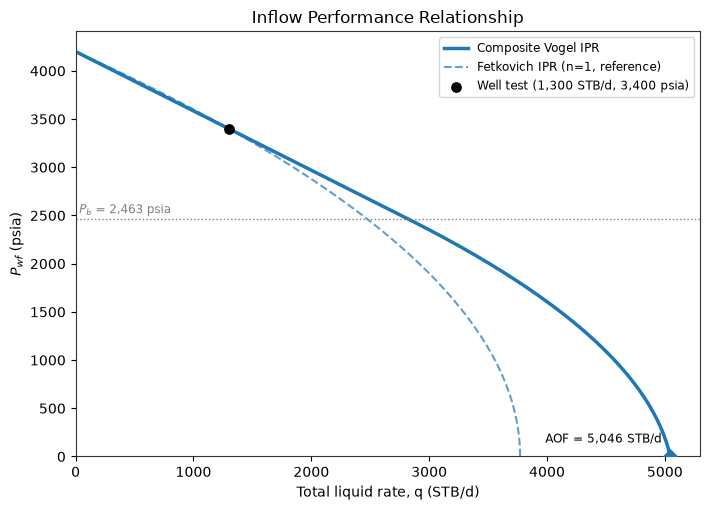

In [7]:

def fetkovich_C(q_test, Pwf_test, Pr, n=1.0):
    return q_test / (Pr ** 2 - Pwf_test ** 2) ** n

def ipr_fetkovich(Pwf, Pr, C, n=1.0):
    Pwf = np.asarray(Pwf, dtype=float)
    return C * np.clip(Pr ** 2 - Pwf ** 2, 0, None) ** n

C_fetk = fetkovich_C(base.q_test, base.Pwf_test, base.Pr)

Pwf_grid = np.linspace(0.01, base.Pr, 200)
q_vogel_grid = ipr_composite(Pwf_grid, base.Pr, Pb, J)
q_fetk_grid = ipr_fetkovich(Pwf_grid, base.Pr, C_fetk)

fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.plot(q_vogel_grid, Pwf_grid, color=C_IPR, lw=2.5, label="Composite Vogel IPR")
ax.plot(q_fetk_grid, Pwf_grid, color=C_IPR, lw=1.5, ls="--", alpha=0.7,
        label="Fetkovich IPR (n=1, reference)")
ax.axhline(Pb, color="gray", ls=":", lw=1)
ax.text(30, Pb + 60, f"$P_b$ = {Pb:,.0f} psia", fontsize=8.5, color="gray")
ax.scatter([base.q_test], [base.Pwf_test], color="black", zorder=5, s=45,
           label=f"Well test ({base.q_test:,.0f} STB/d, {base.Pwf_test:,.0f} psia)")
ax.scatter([qmax_AOF], [0], color=C_IPR, marker="D", s=45, zorder=5)
ax.annotate(f"AOF = {qmax_AOF:,.0f} STB/d", (qmax_AOF, 0), textcoords="offset points",
            xytext=(-90, 10), fontsize=8.5)
ax.set_xlabel("Total liquid rate, q (STB/d)"); ax.set_ylabel("$P_{wf}$ (psia)")
ax.set_title("Inflow Performance Relationship")
ax.set_xlim(0, qmax_AOF * 1.05); ax.set_ylim(0, base.Pr * 1.05)
ax.legend(fontsize=8.5)
fig.tight_layout(); plt.show()


In [8]:

def beggs_brill_gradient(P, T, d_ft, angle_deg, qo, qw, GOR, gg, API, Pb, Rsb,
                          roughness_in=0.0006):
    """Local two-phase pressure gradient dP/dz (psi/ft, positive = pressure builds
    going downward), plus diagnostics (flow regime, liquid holdup, mixture density)."""
    go = oil_sg(API); gw = 1.07

    Rs, Bo, rho_o = oil_pvt(P, gg, API, T, Pb, Rsb)
    Bw, rho_w_sc, mu_w = water_pvt(T)
    rho_w = rho_w_sc / Bw
    mu_o = beggs_robinson_muo(P, T, API, Rs, Pb)
    sigma = baker_swerdloff_ift(P, API, T)

    Z = gas_z(P, T, gg)
    Bg = gas_bg(P, T, Z)
    rho_g = gas_rho(P, T, Z, gg)
    mu_g = lee_gas_visc(P, T, Z, gg)

    qo_d, qw_d = qo * Bo, qw * Bw
    ql_d = qo_d + qw_d
    fo = qo_d / ql_d if ql_d > 0 else 1.0
    rho_L = rho_o * fo + rho_w * (1 - fo)
    mu_L = mu_o * fo + mu_w * (1 - fo)

    qg_free_scfd = max(GOR - Rs, 0) * qo
    qg_d = qg_free_scfd * Bg

    A = np.pi / 4 * d_ft ** 2
    v_sl = 5.615 * ql_d / (86400 * A)
    v_sg = qg_d / (86400 * A)
    v_m = v_sl + v_sg
    lam_L = v_sl / v_m if v_m > 0 else 1.0

    N_Fr = v_m ** 2 / (G * d_ft)
    N_Lv = 1.938 * v_sl * (rho_L / max(sigma, 0.1)) ** 0.25

    L1 = 316 * lam_L ** 0.302
    L2 = 0.0009252 * lam_L ** -2.4684
    L3 = 0.10 * lam_L ** -1.4516
    L4 = 0.5 * lam_L ** -6.738

    if (lam_L < 0.01 and N_Fr < L1) or (lam_L >= 0.01 and N_Fr < L2):
        regime = "segregated"
    elif lam_L >= 0.01 and L2 <= N_Fr <= L3:
        regime = "transition"
    elif (0.01 <= lam_L < 0.4 and L3 < N_Fr <= L1) or (lam_L >= 0.4 and L3 < N_Fr <= L4):
        regime = "intermittent"
    else:
        regime = "distributed"

    coeffs = {"segregated": (0.98, 0.4846, 0.0868),
              "intermittent": (0.845, 0.5351, 0.0173),
              "distributed": (1.065, 0.5824, 0.0609)}

    def HL0(reg):
        a, b, c = coeffs[reg]
        return max(a * lam_L ** b / N_Fr ** c, lam_L)

    if regime == "transition":
        A_t = (L3 - N_Fr) / (L3 - L2)
        HL0_val = A_t * HL0("segregated") + (1 - A_t) * HL0("intermittent")
        reg_incl = "intermittent"
    else:
        HL0_val = HL0(regime)
        reg_incl = regime

    incl_coeffs = {"segregated": (0.011, -3.768, 3.539, -1.614),
                   "intermittent": (2.96, 0.305, -0.4473, 0.0978),
                   "distributed": None}
    theta = np.radians(angle_deg)
    if incl_coeffs[reg_incl] is None:
        psi = 1.0
    else:
        dd, e, f, gexp = incl_coeffs[reg_incl]
        inside = max(dd * lam_L ** e * N_Lv ** f * N_Fr ** gexp, 1e-6)
        Cc = max((1 - lam_L) * np.log(inside), 0.0)
        psi = 1 + Cc * (np.sin(1.8 * theta) - 0.333 * np.sin(1.8 * theta) ** 3)

    H_L = min(max(HL0_val * psi, lam_L), 1.0)

    rho_ns = rho_L * lam_L + rho_g * (1 - lam_L)
    mu_ns = mu_L * lam_L + mu_g * (1 - lam_L)
    rho_m = rho_L * H_L + rho_g * (1 - H_L)

    N_Re_ns = 1488 * rho_ns * v_m * d_ft / mu_ns if mu_ns > 0 else 1e6
    eps_rel = roughness_in / (d_ft * 12)
    f_n = 0.25 / (np.log10(eps_rel / 3.7 + 5.74 / max(N_Re_ns, 1) ** 0.9)) ** 2

    y = lam_L / H_L ** 2 if H_L > 0 else 1.0
    if 1.0 < y < 1.2:
        S = np.log(2.2 * y - 1.2)
    else:
        ln_y = np.log(y) if y > 0 else 0.0
        denom = -0.0523 + 3.182*ln_y - 0.8725*ln_y**2 + 0.01853*ln_y**4
        S = ln_y / denom if abs(denom) > 1e-6 else 0.0
    S = np.clip(S, -5, 5)
    f_tp = f_n * np.exp(S)

    dpdz_el = rho_m * np.sin(theta) / 144.0
    dpdz_f = f_tp * rho_ns * v_m ** 2 / (2 * G * d_ft) / 144.0
    Ek = min(v_m * v_sg * rho_ns / (G * P * 144.0), 0.6) if P > 0 else 0.0
    dpdz = (dpdz_el + dpdz_f) / (1 - Ek)
    return dpdz, regime, H_L, rho_m


def vlp_traverse(Pwh, qo, qw, GOR, wc_case, depth_ft, d_in, gg, API, T_res, T_wh,
                  angle_deg=90, Pb=None, Rsb=None, n_steps=45, roughness_in=0.0006,
                  return_profile=False):
    """March pressure from the wellhead down to bottomhole. Returns Pwf (psia),
    or (Pwf, depth_array, pressure_array) if return_profile=True."""
    d_ft = d_in / 12
    if Pb is None: Pb = standing_pb(GOR, gg, API, T_res)
    if Rsb is None: Rsb = GOR
    dz = depth_ft / n_steps
    P = Pwh
    zs, Ps = [0.0], [Pwh]
    for i in range(n_steps):
        z_mid = (i + 0.5) * dz
        T = T_wh + (T_res - T_wh) * z_mid / depth_ft
        dpdz, *_ = beggs_brill_gradient(P, T, d_ft, angle_deg, qo, qw, GOR, gg, API, Pb, Rsb,
                                         roughness_in)
        P += dpdz * dz
        if return_profile:
            zs.append((i + 1) * dz); Ps.append(P)
    if return_profile:
        return P, np.array(zs), np.array(Ps)
    return P



def vlp_traverse_survey(Pwh, qo, qw, GOR, wc_case, survey, d_in, gg, API, T_res, T_wh,
                         Pb=None, Rsb=None, roughness_in=0.0006, return_profile=False):
    """Pressure traverse for Directional / Custom wells using a wellbore survey.

    Parameters
    ----------
    survey : pd.DataFrame
        Must contain columns  MD_ft, TVD_ft, INC_code_deg
        (INC_code_deg follows Beggs-Brill convention: 90 = vertical, 0 = horizontal).
    All other parameters identical to  vlp_traverse().

    The integration marches along measured depth (MD). Temperature is interpolated
    linearly in TVD space; the Beggs-Brill gradient accounts for local inclination.

    Returns
    -------
    Pwf  (psia)
      or  (Pwf, md_array, pressure_array)  when return_profile=True.
    """
    d_ft = d_in / 12
    if Pb  is None: Pb  = standing_pb(GOR, gg, API, T_res)
    if Rsb is None: Rsb = GOR

    total_tvd = float(survey['TVD_ft'].iloc[-1])
    P  = Pwh
    mds, Ps = [float(survey['MD_ft'].iloc[0])], [Pwh]

    for i in range(1, len(survey)):
        md1  = float(survey['MD_ft'].iloc[i-1])
        md2  = float(survey['MD_ft'].iloc[i])
        tvd1 = float(survey['TVD_ft'].iloc[i-1])
        tvd2 = float(survey['TVD_ft'].iloc[i])
        ic1  = float(survey['INC_code_deg'].iloc[i-1])
        ic2  = float(survey['INC_code_deg'].iloc[i])

        dmd     = md2 - md1
        tvd_mid = (tvd1 + tvd2) * 0.5
        ic_mid  = (ic1  + ic2)  * 0.5

        # Linear temperature interpolation in TVD
        T = T_wh + (T_res - T_wh) * tvd_mid / max(total_tvd, 1.0)

        dpdz, *_ = beggs_brill_gradient(
            P, T, d_ft, ic_mid, qo, qw, GOR, gg, API, Pb, Rsb, roughness_in)

        P += dpdz * dmd          # march along measured depth

        if return_profile:
            mds.append(md2); Ps.append(P)

    if return_profile:
        return P, np.array(mds), np.array(Ps)
    return P


def vlp_pwf_of_q(q, case, Pb, Rsb):
    """Convenience wrapper: total liquid rate q -> required Pwf, given a WellCase.

    Dispatches automatically:
      - Vertical / Horizontal  : single-angle  vlp_traverse()
      - Directional / Custom   : survey-based  vlp_traverse_survey()
    """
    qo, qw = q * (1 - case.wc), q * case.wc
    sv = WELL_CONFIG.get('survey')
    if sv is not None:
        return vlp_traverse_survey(
            case.Pwh, qo, qw, case.GOR, case.wc, sv,
            case.d_in, case.gg, case.API, case.T_res, case.T_wh,
            Pb, Rsb, roughness_in=case.roughness_in)
    else:
        angle = WELL_CONFIG.get('angle_deg')
        if angle is None:
            angle = case.angle_deg
        return vlp_traverse(
            case.Pwh, qo, qw, case.GOR, case.wc, case.depth, case.d_in,
            case.gg, case.API, case.T_res, case.T_wh, angle,
            Pb, Rsb, roughness_in=case.roughness_in)


print("Beggs & Brill VLP engine loaded.")


Beggs & Brill VLP engine loaded.


In [9]:

def solve_operating_point(case, Pr, Pb, J, q_bracket=None, n_scan=80):
    """Find the stable nodal intersection (q*, Pwf*) — rightmost IPR/VLP crossing.

    When the VLP is U-shaped (multiphase), there can be TWO crossings:
      • Left crossing  (low q) — unstable equilibrium, inside the liquid-loading zone
      • Right crossing (high q) — stable operating point
    We collect ALL crossings and return the LAST (rightmost) one.
    """
    Rsb_local = case.GOR

    def ipr_pwf_of_q(q):
        def f(pwf): return ipr_composite(pwf, Pr, Pb, J) - q
        try:
            return brentq(f, 0.01, Pr, xtol=1e-3)
        except ValueError:
            return None

    def diff(q):
        pwf_vlp = vlp_pwf_of_q(q, replace(case, Pwh=case.Pwh), Pb, Rsb_local)
        pwf_ipr = ipr_pwf_of_q(q)
        return None if pwf_ipr is None else pwf_vlp - pwf_ipr

    qmax_ipr = ipr_composite(0.01, Pr, Pb, J)
    lo, hi   = (q_bracket or (5, qmax_ipr * 0.995))
    qs = np.linspace(lo, hi, n_scan)
    ds = [diff(q) for q in qs]

    # Collect ALL sign-change brackets
    crossings = []
    for i in range(len(qs) - 1):
        if ds[i] is None or ds[i + 1] is None:
            continue
        if ds[i] * ds[i + 1] < 0:
            crossings.append((qs[i], qs[i + 1]))

    if not crossings:
        return None, None

    # RIGHTMOST crossing = stable operating point (leftmost = unstable / loading zone)
    q_lo_c, q_hi_c = crossings[-1]
    q_star  = brentq(lambda q: diff(q), q_lo_c, q_hi_c, xtol=0.5)
    Pwf_star = vlp_pwf_of_q(q_star, case, Pb, Rsb_local)
    return q_star, Pwf_star


q_op, Pwf_op = solve_operating_point(base, base.Pr, Pb, J)
print(f"OPERATING POINT:  q* = {q_op:,.0f} STB/d total liquid  "
      f"({q_op*(1-base.wc):,.0f} STB/d oil, {q_op*base.wc:,.0f} STB/d water)   "
      f"|  Pwf* = {Pwf_op:,.0f} psia")


OPERATING POINT:  q* = 2,267 STB/d total liquid  (1,814 STB/d oil, 453 STB/d water)   |  Pwf* = 2,805 psia


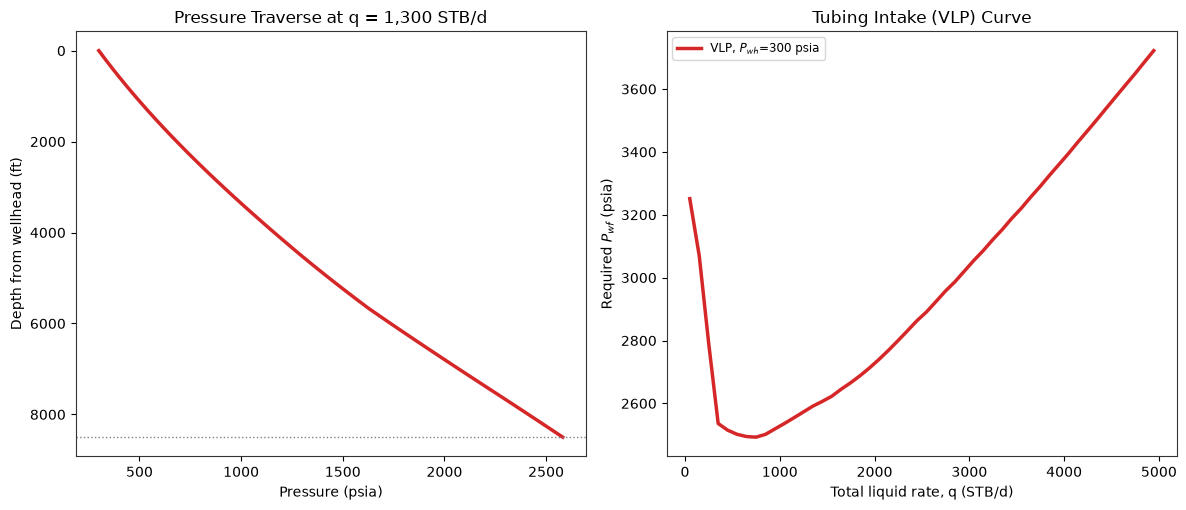

In [10]:
# ── Auto-adaptive sweep ranges ──
q_sweep = np.linspace(max(20, qmax_AOF * 0.01), qmax_AOF * 0.98, 50)
Pwf_vlp_sweep = np.array([vlp_pwf_of_q(q, base, Pb, Rsb) for q in q_sweep])

Pwf_design, z_prof, P_prof = vlp_traverse(
    base.Pwh, base.q_test*(1-base.wc), base.q_test*base.wc, base.GOR, base.wc,
    base.depth, base.d_in, base.gg, base.API, base.T_res, base.T_wh,
    Pb=Pb, Rsb=Rsb, return_profile=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 5.2))

axs[0].plot(P_prof, z_prof, color=C_VLP, lw=2.5)
axs[0].invert_yaxis()
axs[0].set_xlabel("Pressure (psia)"); axs[0].set_ylabel("Depth from wellhead (ft)")
axs[0].set_title(f"Pressure Traverse at q = {base.q_test:,.0f} STB/d")
axs[0].axhline(base.depth, color="gray", ls=":", lw=1)

axs[1].plot(q_sweep, Pwf_vlp_sweep, color=C_VLP, lw=2.5, label=f"VLP, $P_{{wh}}$={base.Pwh:,.0f} psia")
axs[1].set_xlabel("Total liquid rate, q (STB/d)"); axs[1].set_ylabel("Required $P_{wf}$ (psia)")
axs[1].set_title("Tubing Intake (VLP) Curve")
axs[1].legend(fontsize=8.5)

fig.tight_layout(); plt.show()


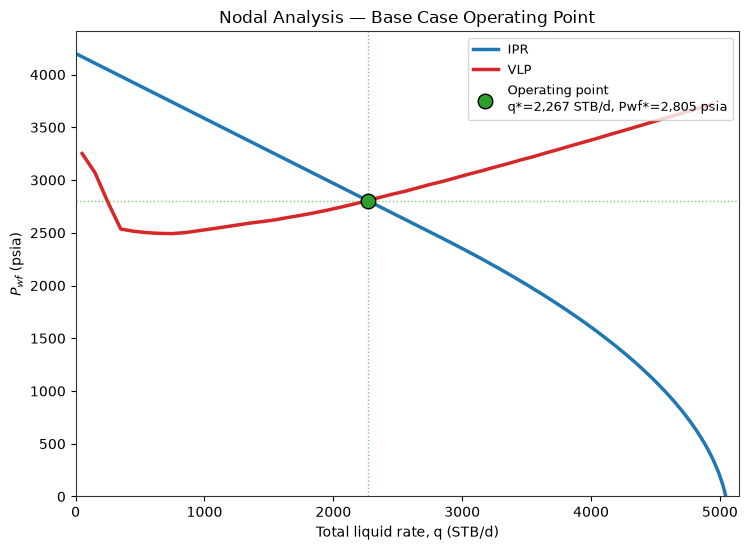

In [11]:
Pwf_grid = np.linspace(0.01, base.Pr, 200)
Pwf_ipr_sweep = ipr_composite(Pwf_grid, base.Pr, Pb, J)   # reuse grid: q(Pwf)

fig, ax = plt.subplots(figsize=(7.6, 5.6))
ax.plot(Pwf_ipr_sweep, Pwf_grid, color=C_IPR, lw=2.5, label="IPR")
ax.plot(q_sweep, Pwf_vlp_sweep, color=C_VLP, lw=2.5, label="VLP")
ax.scatter([q_op], [Pwf_op], color=C_OP, s=110, zorder=6, edgecolor="black",
           label=f"Operating point\nq*={q_op:,.0f} STB/d, Pwf*={Pwf_op:,.0f} psia")
ax.axvline(q_op, color=C_OP, ls=":", lw=1, alpha=0.6)
ax.axhline(Pwf_op, color=C_OP, ls=":", lw=1, alpha=0.6)
ax.set_xlabel("Total liquid rate, q (STB/d)"); ax.set_ylabel("$P_{wf}$ (psia)")
ax.set_title("Nodal Analysis — Base Case Operating Point")
ax.set_xlim(0, qmax_AOF*1.02); ax.set_ylim(0, base.Pr*1.05)
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout(); plt.show()


Using Vertical well default tubing catalog: ['1.900" (1.610 in ID)', '2-3/8" (1.995 in ID)', '2-7/8" (2.441 in ID)', '3-1/2" (2.992 in ID)', '4-1/2" (3.958 in ID)']


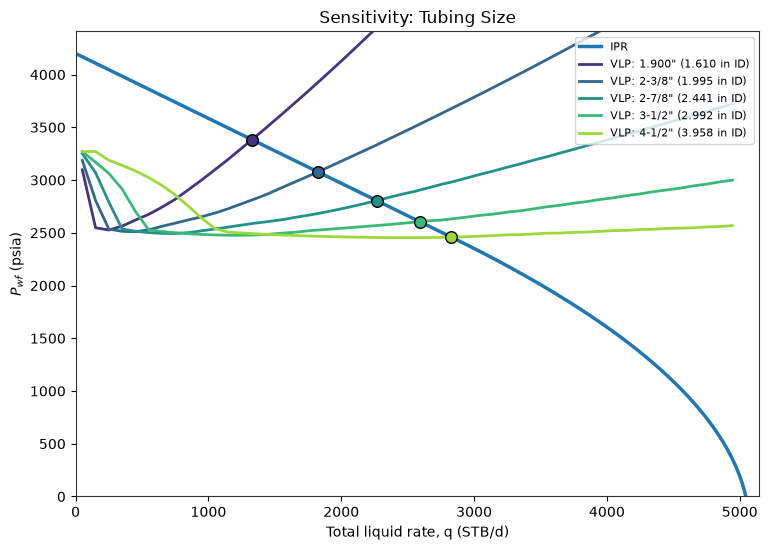

,Tubing,ID (in),q* (STB/d),Pwf* (psia)
0,"1.900"" (1.610 in ID)",1.610,1328.0,3383.0
1,"2-3/8"" (1.995 in ID)",1.995,1823.0,3078.0
2,"2-7/8"" (2.441 in ID)",2.441,2267.0,2805.0
3,"3-1/2"" (2.992 in ID)",2.992,2595.0,2603.0
4,"4-1/2"" (3.958 in ID)",3.958,2828.0,2459.0


In [12]:
# SENSITIVITY: TUBING SIZE — edit or leave as None for auto-defaults


_user_tubing_sizes = None


# ── Auto default ──
_well_type = WELL_CONFIG.get('well_type', 'Vertical')
if _user_tubing_sizes is not None:
    tubing_sizes = _user_tubing_sizes
    print(f"Using USER-SPECIFIED tubing sizes: {list(tubing_sizes.keys())}")
else:
    tubing_sizes = get_tubing_sensitivity_list(_well_type)
    print(f"Using {_well_type} well default tubing catalog: {list(tubing_sizes.keys())}")

# ── Plot ──
fig, ax = plt.subplots(figsize=(7.8, 5.6))
ax.plot(Pwf_ipr_sweep, Pwf_grid, color=C_IPR, lw=2.5, label="IPR")

results_tubing = []
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(tubing_sizes)))
for (label, d_in_i), c in zip(tubing_sizes.items(), colors):
    case_i = replace(base, d_in=d_in_i)
    Pwf_i = np.array([vlp_pwf_of_q(q, case_i, Pb, Rsb) for q in q_sweep])
    ax.plot(q_sweep, Pwf_i, color=c, lw=2, label=f"VLP: {label}")
    q_i, Pwf_star = solve_operating_point(case_i, base.Pr, Pb, J)
    if q_i:
        ax.scatter([q_i], [Pwf_star], color=c, edgecolor="black", zorder=6, s=70)
    results_tubing.append((label, d_in_i, q_i, Pwf_star))

ax.set_xlabel("Total liquid rate, q (STB/d)"); ax.set_ylabel("$P_{wf}$ (psia)")
ax.set_title("Sensitivity: Tubing Size")
ax.set_xlim(0, qmax_AOF*1.02); ax.set_ylim(0, base.Pr*1.05)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout(); plt.show()

df_tubing = pd.DataFrame(results_tubing, columns=["Tubing", "ID (in)", "q* (STB/d)", "Pwf* (psia)"])
df_tubing["q* (STB/d)"] = df_tubing["q* (STB/d)"].round(0)
df_tubing["Pwf* (psia)"] = df_tubing["Pwf* (psia)"].round(0)
df_tubing


Water-cut sweep values: [0.0, 0.2, 0.4, 0.6, 0.8]  (default)


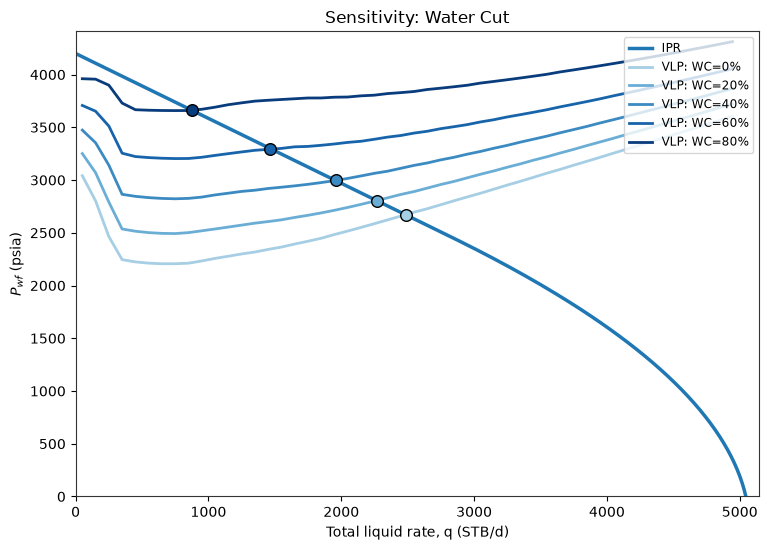

,Water Cut,q* liquid (STB/d),Pwf* (psia),Implied oil rate (STB/d)
0,0%,2485.0,2671.0,2485.0
1,20%,2267.0,2805.0,1814.0
2,40%,1957.0,2996.0,1174.0
3,60%,1467.0,3297.0,587.0
4,80%,877.0,3660.0,175.0


In [13]:
# SENSITIVITY: WATER CUT

_user_wc_values = None       # e.g. [0.0, 0.10, 0.30, 0.50, 0.70, 0.90]

# ── Auto default: 5 equally-spaced values from 0 to 0.80 ──
wc_values = _user_wc_values if _user_wc_values is not None else [0.0, 0.20, 0.40, 0.60, 0.80]
print(f"Water-cut sweep values: {wc_values}  ({'user' if _user_wc_values else 'default'})")

fig, ax = plt.subplots(figsize=(7.8, 5.6))
ax.plot(Pwf_ipr_sweep, Pwf_grid, color=C_IPR, lw=2.5, label="IPR")

results_wc = []
colors = plt.cm.Blues(np.linspace(0.35, 0.95, len(wc_values)))
for wc_i, c in zip(wc_values, colors):
    case_i = replace(base, wc=wc_i)
    Pwf_i = np.array([vlp_pwf_of_q(q, case_i, Pb, Rsb) for q in q_sweep])
    ax.plot(q_sweep, Pwf_i, color=c, lw=2, label=f"VLP: WC={wc_i:.0%}")
    q_i, Pwf_star = solve_operating_point(case_i, base.Pr, Pb, J)
    if q_i:
        ax.scatter([q_i], [Pwf_star], color=c, edgecolor="black", zorder=6, s=70)
    results_wc.append((f"{wc_i:.0%}", q_i, Pwf_star,
                        q_i*(1-wc_i) if q_i else None))

ax.set_xlabel("Total liquid rate, q (STB/d)"); ax.set_ylabel("$P_{wf}$ (psia)")
ax.set_title("Sensitivity: Water Cut")
ax.set_xlim(0, qmax_AOF*1.02); ax.set_ylim(0, base.Pr*1.05)
ax.legend(fontsize=8.5, loc="upper right")
fig.tight_layout(); plt.show()

df_wc = pd.DataFrame(results_wc, columns=["Water Cut", "q* liquid (STB/d)", "Pwf* (psia)",
                                           "Implied oil rate (STB/d)"])
for col in df_wc.columns[1:]:
    df_wc[col] = df_wc[col].round(0)
df_wc


GOR sweep values (scf/STB): [300, 400, 600, 900, 1500]  (auto from base GOR)


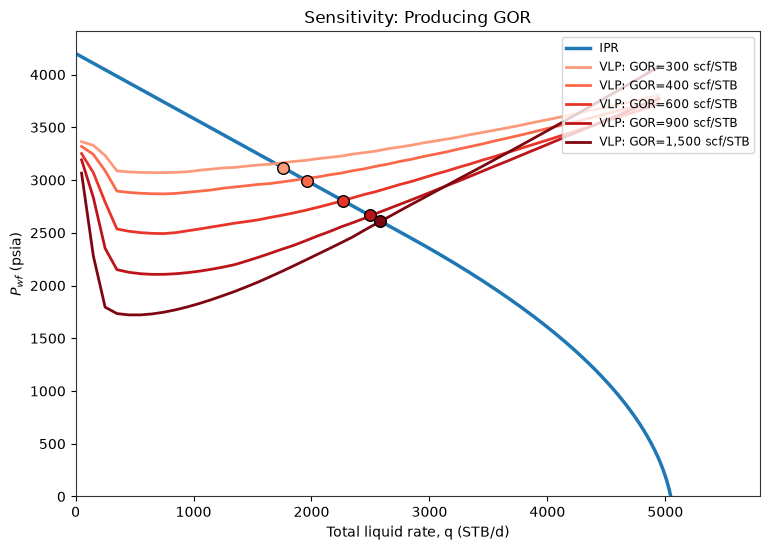

,GOR (scf/STB),Pb (psia),q* (STB/d),Pwf* (psia)
0,300,1374.0,1759.0,3118.0
1,400,1752.0,1960.0,2994.0
2,600,2463.0,2267.0,2805.0
3,900,3459.0,2493.0,2666.0
4,1500,5299.0,2580.0,2613.0


In [14]:
# SENSITIVITY: PRODUCING GOR 

_user_gor_values = None      # e.g. [200, 500, 800, 1200, 2000]

# ── Auto default: 5 values centered around the base GOR ──
if _user_gor_values is not None:
    gor_values = _user_gor_values
else:
    _g = base.GOR
    gor_values = sorted(set([
        max(100, int(round(_g * 0.5, -2))),
        int(round(_g * 0.75, -2)),
        int(round(_g, -2)),
        int(round(_g * 1.5, -2)),
        int(round(_g * 2.5, -2)),
    ]))
print(f"GOR sweep values (scf/STB): {gor_values}  ({'user' if _user_gor_values else 'auto from base GOR'})")

fig, ax = plt.subplots(figsize=(7.8, 5.6))
ax.plot(Pwf_ipr_sweep, Pwf_grid, color=C_IPR, lw=2.5, label="IPR")

results_gor = []
colors = plt.cm.Reds(np.linspace(0.35, 0.95, len(gor_values)))
for gor_i, c in zip(gor_values, colors):
    case_i = replace(base, GOR=gor_i)
    Pb_i = standing_pb(gor_i, base.gg, base.API, base.T_res)
    Pwf_i = np.array([vlp_pwf_of_q(q, case_i, Pb_i, gor_i) for q in q_sweep])
    ax.plot(q_sweep, Pwf_i, color=c, lw=2, label=f"VLP: GOR={gor_i:,.0f} scf/STB")
    q_i, Pwf_star = solve_operating_point(case_i, base.Pr, Pb,J)
    if q_i:
        ax.scatter([q_i], [Pwf_star], color=c, edgecolor="black", zorder=6, s=70)
    results_gor.append((gor_i, round(Pb_i, 0), q_i, Pwf_star))

ax.set_xlabel("Total liquid rate, q (STB/d)"); ax.set_ylabel("$P_{wf}$ (psia)")
ax.set_title("Sensitivity: Producing GOR")
ax.set_xlim(0, qmax_AOF*1.15); ax.set_ylim(0, base.Pr*1.05)
ax.legend(fontsize=8.5, loc="upper right")
fig.tight_layout(); plt.show()

df_gor = pd.DataFrame(results_gor, columns=["GOR (scf/STB)", "Pb (psia)", "q* (STB/d)", "Pwf* (psia)"])
df_gor["q* (STB/d)"] = df_gor["q* (STB/d)"].round(0)
df_gor["Pwf* (psia)"] = df_gor["Pwf* (psia)"].round(0)
df_gor


Depletion Pr values (psia): [4200, 3700, 3200, 2700, 2200, 1700]  (auto from base Pr)


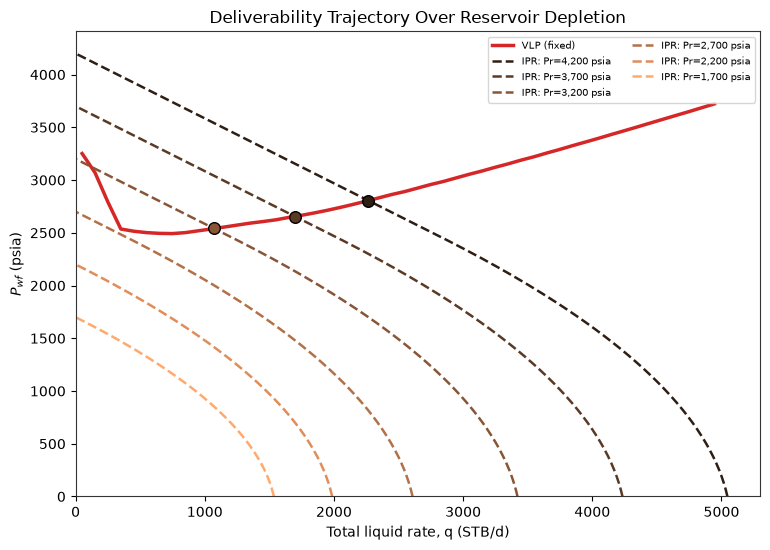

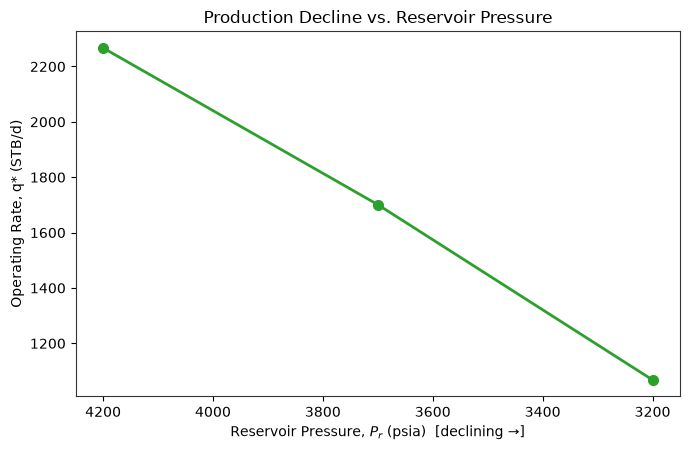

,Pr (psia),q* (STB/d),Pwf* (psia)
0,4200,2267.0,2805.0
1,3700,1701.0,2653.0
2,3200,1068.0,2543.0
3,2700,NaN,NaN
4,2200,NaN,NaN
5,1700,NaN,NaN


In [15]:
# RESERVOIR DEPLETION

_user_Pr_values = None       # e.g. [4000, 3500, 3000, 2500, 2000, 1500]

# ── Auto default: 6 evenly-spaced values from Pr down to ~40% of Pr ──
if _user_Pr_values is not None:
    Pr_values = _user_Pr_values
else:
    Pr_values = [int(round(v, -2)) for v in np.linspace(base.Pr, base.Pr * 0.40, 6)]
print(f"Depletion Pr values (psia): {Pr_values}  ({'user' if _user_Pr_values else 'auto from base Pr'})")

results_depl = []
fig, ax = plt.subplots(figsize=(7.8, 5.6))
colors = plt.cm.copper(np.linspace(0.15, 0.85, len(Pr_values)))

ax.plot(q_sweep, Pwf_vlp_sweep, color=C_VLP, lw=2.5, label="VLP (fixed)")
for Pr_i, c in zip(Pr_values, colors):
    q_grid_i = ipr_composite(Pwf_grid, Pr_i, Pb, J)
    ax.plot(q_grid_i, Pwf_grid, color=c, lw=1.8, ls="--", label=f"IPR: Pr={Pr_i:,.0f} psia")
    try:
        q_i, Pwf_star = solve_operating_point(base, Pr_i, Pb, J,
                                               q_bracket=(5, ipr_composite(0.01, Pr_i, Pb, J)*0.995))
    except Exception:
        q_i, Pwf_star = None, None
    if q_i:
        ax.scatter([q_i], [Pwf_star], color=c, edgecolor="black", zorder=6, s=70)
    results_depl.append((Pr_i, q_i, Pwf_star))

ax.set_xlabel("Total liquid rate, q (STB/d)"); ax.set_ylabel("$P_{wf}$ (psia)")
ax.set_title("Deliverability Trajectory Over Reservoir Depletion")
ax.set_xlim(0, qmax_AOF*1.05); ax.set_ylim(0, base.Pr*1.05)
ax.legend(fontsize=7.5, loc="upper right", ncol=2)
fig.tight_layout(); plt.show()

df_depl = pd.DataFrame(results_depl, columns=["Pr (psia)", "q* (STB/d)", "Pwf* (psia)"])
df_depl["q* (STB/d)"] = df_depl["q* (STB/d)"].round(0)
df_depl["Pwf* (psia)"] = df_depl["Pwf* (psia)"].round(0)

fig2, ax2 = plt.subplots(figsize=(7, 4.6))
_valid = df_depl.dropna(subset=["q* (STB/d)"])
ax2.plot(_valid["Pr (psia)"], _valid["q* (STB/d)"], "o-", color=C_OP, lw=2, ms=7)
ax2.invert_xaxis()
ax2.set_xlabel("Reservoir Pressure, $P_r$ (psia)  [declining →]")
ax2.set_ylabel("Operating Rate, q* (STB/d)")
ax2.set_title("Production Decline vs. Reservoir Pressure")
fig2.tight_layout(); plt.show()

df_depl


Pwh sweep values (psia): [100, 400, 600, 900, 1200]  (auto)


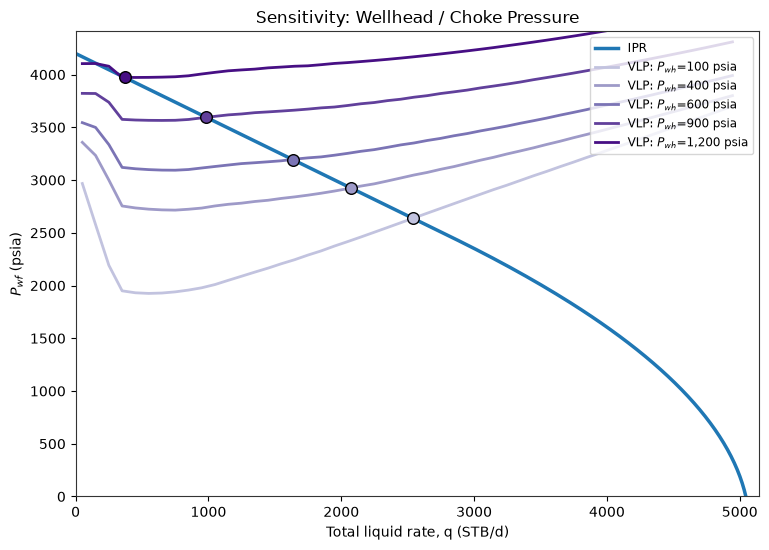

,Pwh (psia),q* (STB/d),Pwf* (psia)
0,100,2539.0,2637.0
1,400,2074.0,2923.0
2,600,1637.0,3192.0
3,900,981.0,3596.0
4,1200,369.0,3973.0


In [16]:
# SENSITIVITY: WELLHEAD / CHOKE PRESSURE 

_user_Pwh_values = None      # e.g. [50, 200, 400, 600, 1000]

# ── Auto default: 5 values from 100 psia up to ~3x base Pwh ──
if _user_Pwh_values is not None:
    Pwh_values = _user_Pwh_values
else:
    _top = max(base.Pwh * 3.5, 1200)
    Pwh_values = [int(round(v, -2)) for v in np.linspace(100, _top, 5)]
print(f"Pwh sweep values (psia): {Pwh_values}  ({'user' if _user_Pwh_values else 'auto'})")

results_pwh = []
fig, ax = plt.subplots(figsize=(7.8, 5.6))
ax.plot(Pwf_ipr_sweep, Pwf_grid, color=C_IPR, lw=2.5, label="IPR")
colors = plt.cm.Purples(np.linspace(0.35, 0.95, len(Pwh_values)))

for Pwh_i, c in zip(Pwh_values, colors):
    case_i = replace(base, Pwh=Pwh_i)
    Pwf_i = np.array([vlp_pwf_of_q(q, case_i, Pb, Rsb) for q in q_sweep])
    ax.plot(q_sweep, Pwf_i, color=c, lw=2, label=f"VLP: $P_{{wh}}$={Pwh_i:,.0f} psia")
    q_i, Pwf_star = solve_operating_point(case_i, base.Pr, Pb, J)
    if q_i:
        ax.scatter([q_i], [Pwf_star], color=c, edgecolor="black", zorder=6, s=70)
    results_pwh.append((Pwh_i, q_i, Pwf_star))

ax.set_xlabel("Total liquid rate, q (STB/d)"); ax.set_ylabel("$P_{wf}$ (psia)")
ax.set_title("Sensitivity: Wellhead / Choke Pressure")
ax.set_xlim(0, qmax_AOF*1.02); ax.set_ylim(0, base.Pr*1.05)
ax.legend(fontsize=8.5, loc="upper right")
fig.tight_layout(); plt.show()

df_pwh = pd.DataFrame(results_pwh, columns=["Pwh (psia)", "q* (STB/d)", "Pwf* (psia)"])
df_pwh["q* (STB/d)"] = df_pwh["q* (STB/d)"].round(0)
df_pwh["Pwf* (psia)"] = df_pwh["Pwf* (psia)"].round(0)
df_pwh


Injection depth: 5,950 ft  (auto = 70% of TVD)
GLR sweep (MMscf/d): [0, 0.5, 1, 1.5, 2, 3, 4, 6, 8, 10, 15, 20]  (default)


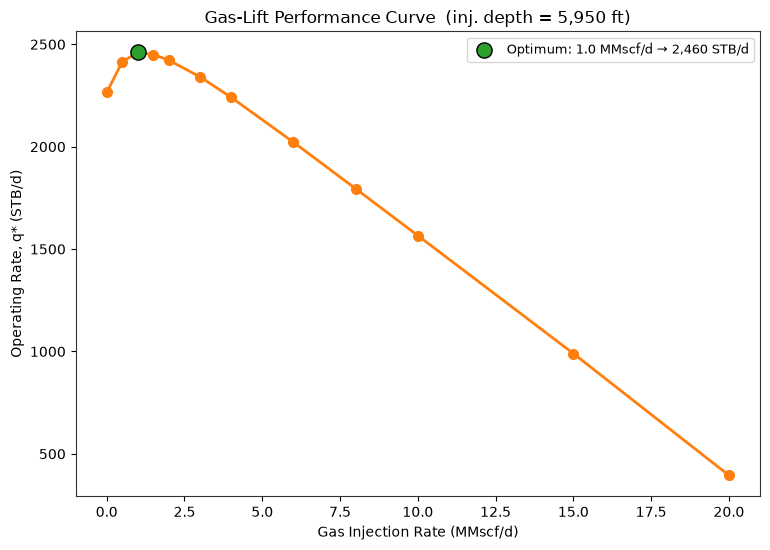


Optimum continuous gas-lift: inject 1.0 MMscf/d at 5,950 ft → q* = 2,460 STB/d


,Gas Lift Rate (MMscf/d),q* (STB/d),Pwf* (psia)
0,0.0,2265.0,2806.0
1,0.5,2415.0,2714.0
2,1.0,2460.0,2686.0
3,1.5,2450.0,2692.0
4,2.0,2422.0,2709.0
5,3.0,2341.0,2759.0
6,4.0,2241.0,2821.0
7,6.0,2022.0,2956.0
8,8.0,1795.0,3096.0
9,10.0,1566.0,3236.0


In [17]:
# ARTIFICIAL LIFT: CONTINUOUS GAS-LIFT 

_user_inj_depth     = None   # ft    — gas-lift injection depth   (default: 70% of TVD)
_user_glr_mmscfd    = None   # list  — injection rates in MMscf/d (default: auto range)

# ── Auto defaults ──
inj_depth = _user_inj_depth if _user_inj_depth is not None else round(base.depth * 0.70, 0)
if _user_glr_mmscfd is not None:
    glr_values_mmscfd = _user_glr_mmscfd
else:
    glr_values_mmscfd = [0, 0.5, 1, 1.5, 2, 3, 4, 6, 8, 10, 15, 20]
print(f"Injection depth: {inj_depth:,.0f} ft  ({'user' if _user_inj_depth else 'auto = 70% of TVD'})")
print(f"GLR sweep (MMscf/d): {glr_values_mmscfd}  ({'user' if _user_glr_mmscfd else 'default'})")

def vlp_pwf_gaslift(Pwh, qo, qw, GOR_res, gas_lift_scfd, inj_depth_ft, case, Pb, Rsb,
                     n_steps=50):
    """Two-segment Beggs & Brill traverse with continuous gas-lift injection at inj_depth_ft."""
    d_ft = case.d_in / 12
    GLR_inj = gas_lift_scfd / qo if qo > 0 else 0.0
    GOR_above = GOR_res + GLR_inj

    n1 = max(int(n_steps * inj_depth_ft / case.depth), 1)
    n2 = max(n_steps - n1, 1)
    P = Pwh
    dz1 = inj_depth_ft / n1
    for i in range(n1):
        z_mid = (i + 0.5) * dz1
        T = case.T_wh + (case.T_res - case.T_wh) * z_mid / case.depth
        dpdz, *_ = beggs_brill_gradient(P, T, d_ft, case.angle_deg, qo, qw, GOR_above,
                                         case.gg, case.API, Pb, Rsb, case.roughness_in)
        P += dpdz * dz1
    dz2 = (case.depth - inj_depth_ft) / n2
    for i in range(n2):
        z_mid = inj_depth_ft + (i + 0.5) * dz2
        T = case.T_wh + (case.T_res - case.T_wh) * z_mid / case.depth
        dpdz, *_ = beggs_brill_gradient(P, T, d_ft, case.angle_deg, qo, qw, GOR_res,
                                         case.gg, case.API, Pb, Rsb, case.roughness_in)
        P += dpdz * dz2
    return P

def solve_op_point_gaslift(case, Pr, Pb, J, gas_lift_scfd, inj_depth_ft, n_scan=60):
    def ipr_pwf_of_q(q):
        def f(pwf): return ipr_composite(pwf, Pr, Pb, J) - q
        try: return brentq(f, 0.01, Pr, xtol=1e-3)
        except ValueError: return None
    def diff(q):
        qo, qw = q*(1-case.wc), q*case.wc
        pwf_vlp = vlp_pwf_gaslift(case.Pwh, qo, qw, case.GOR, gas_lift_scfd, inj_depth_ft,
                                   case, Pb, case.GOR)
        pwf_ipr = ipr_pwf_of_q(q)
        return None if pwf_ipr is None else pwf_vlp - pwf_ipr
    qmax_ipr = ipr_composite(0.01, Pr, Pb, J)
    qs = np.linspace(5, qmax_ipr*0.995, n_scan)
    ds = [diff(q) for q in qs]
    for i in range(len(qs)-1):
        if ds[i] is None or ds[i+1] is None: continue
        if ds[i]*ds[i+1] < 0:
            q_star = brentq(diff, qs[i], qs[i+1], xtol=0.5)
            qo, qw = q_star*(1-case.wc), q_star*case.wc
            return q_star, vlp_pwf_gaslift(case.Pwh, qo, qw, case.GOR, gas_lift_scfd,
                                            inj_depth_ft, case, Pb, case.GOR)
    return None, None

results_gl = []
for glr_mm in glr_values_mmscfd:
    q_i, Pwf_i = solve_op_point_gaslift(base, base.Pr, Pb, J, glr_mm*1e6, inj_depth)
    results_gl.append((glr_mm, q_i, Pwf_i))

df_gl = pd.DataFrame(results_gl, columns=["Gas Lift Rate (MMscf/d)", "q* (STB/d)", "Pwf* (psia)"])
df_gl["q* (STB/d)"] = df_gl["q* (STB/d)"].round(0)
df_gl["Pwf* (psia)"] = df_gl["Pwf* (psia)"].round(0)

_valid_gl = df_gl.dropna(subset=["q* (STB/d)"])
if len(_valid_gl) > 0:
    i_opt = _valid_gl["q* (STB/d)"].idxmax()
    opt_glr = _valid_gl.loc[i_opt, "Gas Lift Rate (MMscf/d)"]
    opt_q = _valid_gl.loc[i_opt, "q* (STB/d)"]
else:
    i_opt, opt_glr, opt_q = 0, 0, 0

fig, ax = plt.subplots(figsize=(7.8, 5.6))
ax.plot(_valid_gl["Gas Lift Rate (MMscf/d)"], _valid_gl["q* (STB/d)"], "o-", color=C_GAS, lw=2, ms=7)
if opt_q > 0:
    ax.scatter([opt_glr], [opt_q], color=C_OP, edgecolor="black", s=120, zorder=6,
               label=f"Optimum: {opt_glr:.1f} MMscf/d → {opt_q:,.0f} STB/d")
ax.set_xlabel("Gas Injection Rate (MMscf/d)"); ax.set_ylabel("Operating Rate, q* (STB/d)")
ax.set_title(f"Gas-Lift Performance Curve  (inj. depth = {inj_depth:,.0f} ft)")
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

print(f"\nOptimum continuous gas-lift: inject {opt_glr:.1f} MMscf/d at {inj_depth:,.0f} ft "
      f"→ q* = {opt_q:,.0f} STB/d")
df_gl


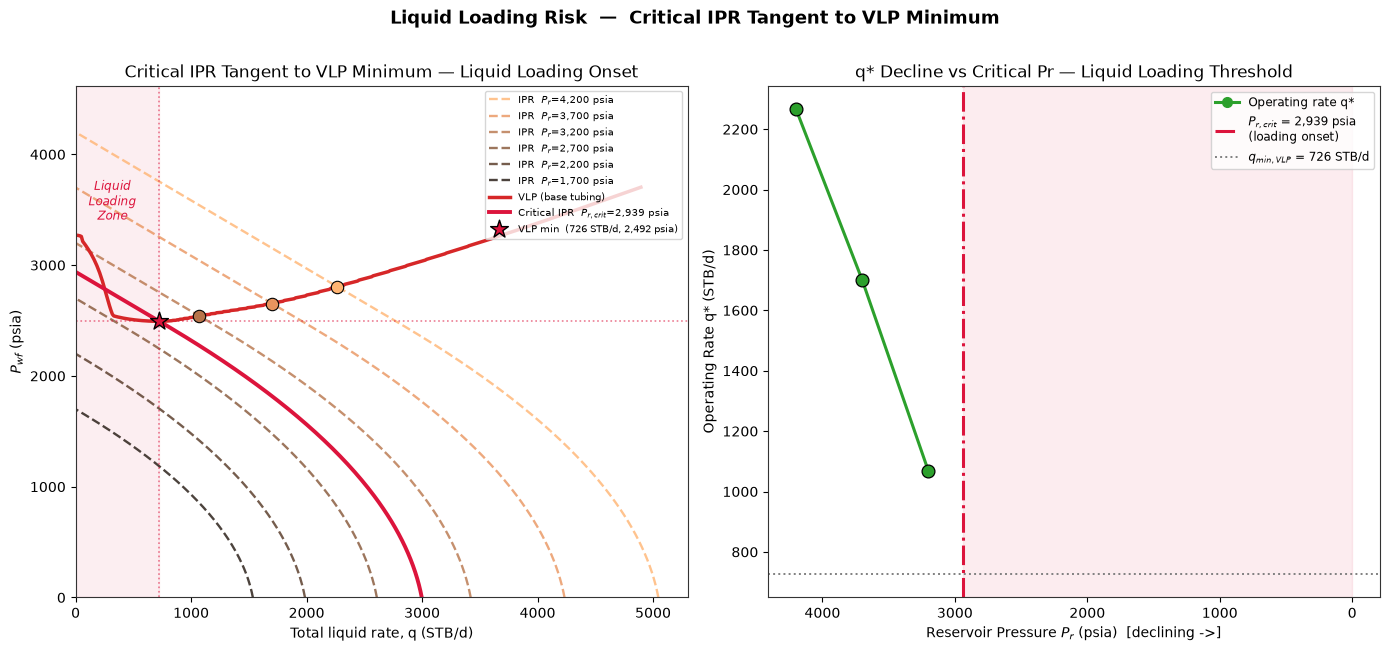

VLP MINIMUM     : q_min  = 726 STB/d  |  Pwf_min = 2,492 psia
CRITICAL Pr     : Pr_crit = 2,939 psia
  -> Below 2,939 psia the stable IPR/VLP intersection disappears.
     Operator must intervene (gas lift, velocity string, plunger) before Pr reaches this threshold.



,Pr (psia),q* (STB/d),q_min_VLP (STB/d),Pwf* (psia),Status
0,4200,2267.192640,726.0,2804.733925,Stable
1,3700,1700.955023,726.0,2653.210109,Stable
2,3200,1068.220529,726.0,2542.693654,Stable
3,2700,NaN,726.0,NaN,!!! LOADING
4,2200,NaN,726.0,NaN,!!! LOADING
5,1700,NaN,726.0,NaN,!!! LOADING


In [18]:
# LIQUID LOADING ANALYSIS  —  Critical IPR from VLP Minimum (physically correct)
#
# The VLP curve is U-shaped in multiphase flow:
#   q < q_min_vlp : hydrostatic column dominates  → liquid accumulates (LOADING)
#   q > q_min_vlp : friction dominates            → stable lifting
#
# The CRITICAL RESERVOIR PRESSURE Pr_crit is the Pr whose IPR passes exactly
# through the VLP minimum (q_min_vlp, Pwf_min_vlp).
#   Pr > Pr_crit : two IPR/VLP crossings — take the rightmost (stable)
#   Pr = Pr_crit : IPR tangent to VLP minimum — last stable operating point
#   Pr < Pr_crit : no stable intersection  — well will load

from scipy.optimize import minimize_scalar

# 1. Locate VLP minimum precisely with a dense sweep + bounded minimization
q_dense   = np.linspace(max(15, qmax_AOF * 0.005), qmax_AOF * 0.97, 400)
Pwf_dense = np.array([vlp_pwf_of_q(q, base, Pb, Rsb) for q in q_dense])

res_min     = minimize_scalar(lambda q: vlp_pwf_of_q(q, base, Pb, Rsb),
                               bounds=(q_dense[0], q_dense[-1]), method='bounded')
q_min_vlp   = res_min.x
Pwf_min_vlp = res_min.fun

# 2. Invert ipr_composite at VLP minimum to get Pr_crit analytically
#    ipr_composite(Pwf, Pr, Pb, J):
#      Pwf >= Pb : q = J*(Pr - Pwf)            => Pr = Pwf + q/J
#      Pwf <  Pb : q = J*(Pr-Pb) + J*Pb/1.8*(1 - 0.2*f - 0.8*f^2)
#                                               => Pr = Pb + (q - q_vogel)/J
f_ratio = Pwf_min_vlp / Pb
if Pwf_min_vlp >= Pb:
    Pr_crit = Pwf_min_vlp + q_min_vlp / J
else:
    q_vogel = J * Pb / 1.8 * (1 - 0.2 * f_ratio - 0.8 * f_ratio**2)
    Pr_crit = Pb + (q_min_vlp - q_vogel) / J

# 3. Corrected operating points for each depletion stage (rightmost intersection)
ll_rows = []
for Pr_i in Pr_values:
    q_star, Pwf_star = solve_operating_point(base, Pr_i, Pb, J)
    at_risk = (q_star is None) or (q_star < q_min_vlp)
    ll_rows.append({'Pr': Pr_i, 'q_star': q_star, 'p_star': Pwf_star,
                    'at_risk': at_risk})

# 4. Dual-panel figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.0, 6.4))
colors_ll = plt.cm.copper_r(np.linspace(0.10, 0.90, len(Pr_values)))
Pwf_g     = np.linspace(0.01, max(Pr_values) * 1.02, 300)

# Panel 1 — IPR family + VLP + critical IPR + VLP minimum marker
for Pr_i, c_i, row in zip(Pr_values, colors_ll, ll_rows):
    q_ipr_i = ipr_composite(Pwf_g, Pr_i, Pb, J)
    ax1.plot(q_ipr_i, Pwf_g, color=c_i, lw=1.7, ls='--', alpha=0.80,
             label=f'IPR  $P_r$={Pr_i:,.0f} psia')
    if row['q_star'] is not None and row['p_star'] is not None:
        mk = 'X' if row['at_risk'] else 'o'
        ax1.scatter([row['q_star']], [row['p_star']],
                    color=c_i, edgecolor='black', s=80, zorder=7,
                    marker=mk, linewidths=0.8)

# VLP with dense resolution
ax1.plot(q_dense, Pwf_dense, color=C_VLP, lw=2.5, label='VLP (base tubing)')

# Critical IPR at Pr_crit (thick solid crimson)
q_ipr_crit = ipr_composite(Pwf_g, Pr_crit, Pb, J)
ax1.plot(q_ipr_crit, Pwf_g, color='crimson', lw=2.8, ls='-',
         label=f'Critical IPR  $P_{{r,crit}}$={Pr_crit:,.0f} psia')

# VLP minimum star
ax1.scatter([q_min_vlp], [Pwf_min_vlp],
            color='crimson', edgecolor='black', s=180, zorder=10, marker='*',
            label=f'VLP min  ({q_min_vlp:,.0f} STB/d, {Pwf_min_vlp:,.0f} psia)')
ax1.axhline(Pwf_min_vlp, color='crimson', ls=':', lw=1.2, alpha=0.55)
ax1.axvline(q_min_vlp,   color='crimson', ls=':', lw=1.2, alpha=0.55)

# Loading zone shading
ax1.axvspan(0, q_min_vlp, alpha=0.07, color='crimson')
ax1.text(q_min_vlp * 0.44, max(Pr_values) * 0.90,
         'Liquid\nLoading\nZone', color='crimson', fontsize=8.5,
         ha='center', va='top', style='italic')

ax1.set_xlabel('Total liquid rate, q (STB/d)')
ax1.set_ylabel('$P_{wf}$ (psia)')
ax1.set_title('Critical IPR Tangent to VLP Minimum — Liquid Loading Onset')
ax1.set_xlim(0, qmax_AOF * 1.05)
ax1.set_ylim(0, max(Pr_values) * 1.10)
ax1.legend(fontsize=7.5, loc='upper right')

# Panel 2 — q* vs Pr, Pr_crit as vertical threshold
valid = [(r['Pr'], r['q_star']) for r in ll_rows if r['q_star'] is not None]
Pr_v  = [v[0] for v in valid]
q_v   = [v[1] for v in valid]
ax2.plot(Pr_v, q_v, 'o-', color=C_OP, lw=2.2, ms=7, zorder=4, label='Operating rate q*')

ax2.axvline(Pr_crit, color='crimson', ls='-.', lw=2.2,
            label=f'$P_{{r,crit}}$ = {Pr_crit:,.0f} psia\n(loading onset)')
ax2.axhline(q_min_vlp, color='gray', ls=':', lw=1.4,
            label=f'$q_{{min,VLP}}$ = {q_min_vlp:,.0f} STB/d')
if Pr_v:
    ax2.axvspan(0, Pr_crit, alpha=0.08, color='crimson')

for r in ll_rows:
    if r['q_star'] is None: continue
    ax2.scatter([r['Pr']], [r['q_star']],
                color='crimson' if r['at_risk'] else C_OP,
                edgecolor='black', s=85, zorder=5,
                marker='X' if r['at_risk'] else 'o', linewidths=0.9)

ax2.invert_xaxis()
ax2.set_xlabel('Reservoir Pressure $P_r$ (psia)  [declining ->]')
ax2.set_ylabel('Operating Rate q* (STB/d)')
ax2.set_title('q* Decline vs Critical Pr — Liquid Loading Threshold')
ax2.legend(fontsize=8.5)

fig.suptitle(
    'Liquid Loading Risk  —  Critical IPR Tangent to VLP Minimum',
    fontweight='bold', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

# Summary
print(f'VLP MINIMUM     : q_min  = {q_min_vlp:,.0f} STB/d  |  '
      f'Pwf_min = {Pwf_min_vlp:,.0f} psia')
print(f'CRITICAL Pr     : Pr_crit = {Pr_crit:,.0f} psia')
print(f'  -> Below {Pr_crit:,.0f} psia the stable IPR/VLP intersection disappears.\n'
      f'     Operator must intervene (gas lift, velocity string, plunger) '
      f'before Pr reaches this threshold.\n')

df_risk = pd.DataFrame({
    'Pr (psia)':          [r['Pr']     for r in ll_rows],
    'q* (STB/d)':         [r['q_star'] for r in ll_rows],
    'q_min_VLP (STB/d)':  [round(q_min_vlp, 0)] * len(ll_rows),
    'Pwf* (psia)':        [r['p_star'] for r in ll_rows],
    'Status':             ['!!! LOADING' if r['at_risk'] else 'Stable'
                           for r in ll_rows],
})
df_risk


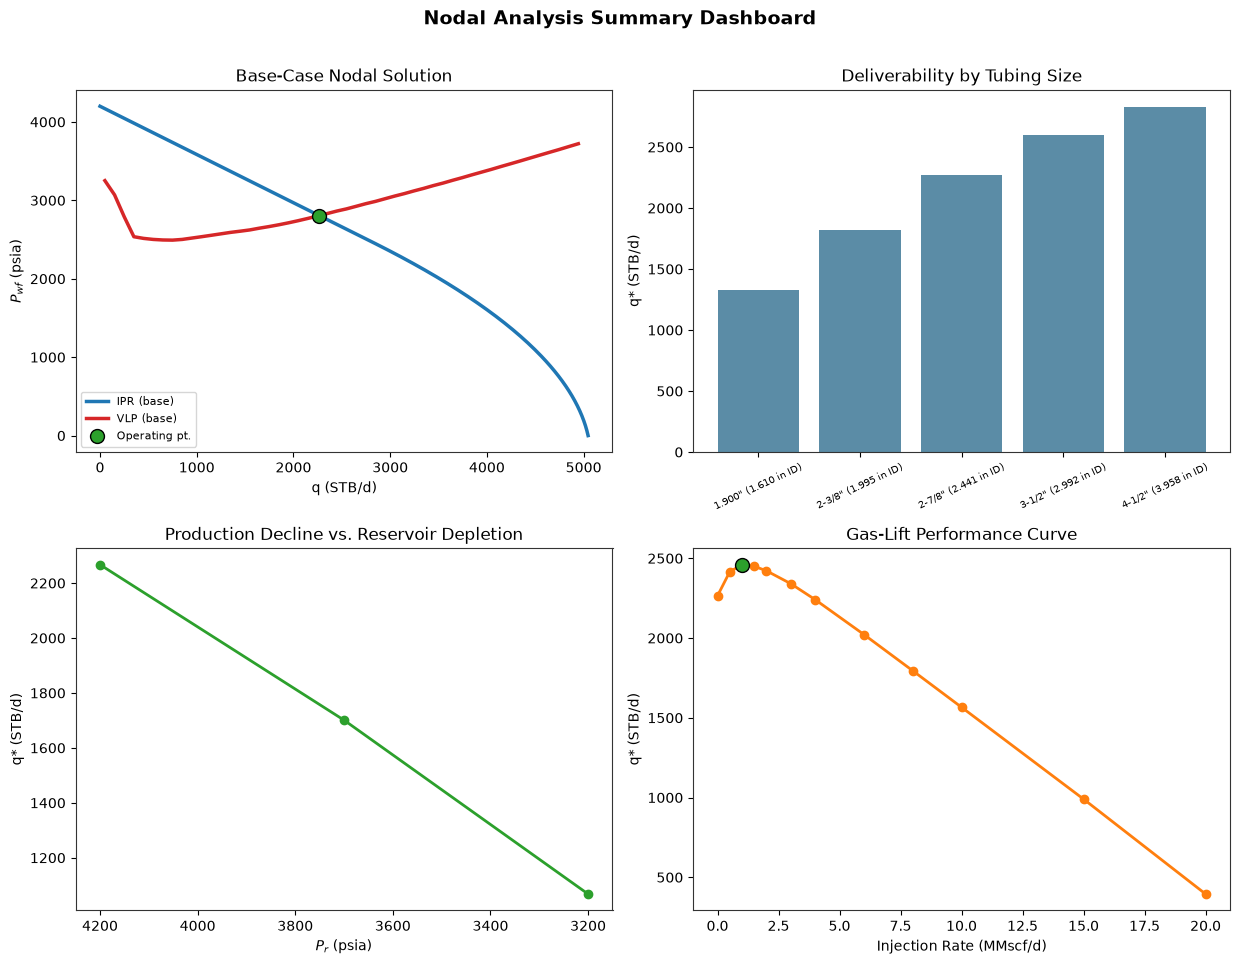

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(12.5, 9.5))

# Panel 1: master nodal plot
ax = axs[0, 0]
ax.plot(Pwf_ipr_sweep, Pwf_grid, color=C_IPR, lw=2.5, label="IPR (base)")
ax.plot(q_sweep, Pwf_vlp_sweep, color=C_VLP, lw=2.5, label="VLP (base)")
ax.scatter([q_op], [Pwf_op], color=C_OP, s=100, zorder=6, edgecolor="black", label="Operating pt.")
ax.set_title("Base-Case Nodal Solution"); ax.set_xlabel("q (STB/d)"); ax.set_ylabel("$P_{wf}$ (psia)")
ax.legend(fontsize=8)

# Panel 2: tubing size comparison (bar)
ax = axs[0, 1]
_valid_tb = df_tubing.dropna(subset=["q* (STB/d)"])
ax.bar(_valid_tb["Tubing"], _valid_tb["q* (STB/d)"], color="#5b8ca6")
ax.set_title("Deliverability by Tubing Size"); ax.set_ylabel("q* (STB/d)")
ax.tick_params(axis="x", rotation=25, labelsize=7.5)

# Panel 3: depletion trajectory
ax = axs[1, 0]
_valid_dp = df_depl.dropna(subset=["q* (STB/d)"])
ax.plot(_valid_dp["Pr (psia)"], _valid_dp["q* (STB/d)"], "o-", color=C_OP, lw=2)
ax.invert_xaxis()
ax.set_title("Production Decline vs. Reservoir Depletion")
ax.set_xlabel("$P_r$ (psia)"); ax.set_ylabel("q* (STB/d)")

# Panel 4: gas lift performance curve
ax = axs[1, 1]
ax.plot(_valid_gl["Gas Lift Rate (MMscf/d)"], _valid_gl["q* (STB/d)"], "o-", color=C_GAS, lw=2)
if opt_q > 0:
    ax.scatter([opt_glr], [opt_q], color=C_OP, edgecolor="black", s=100, zorder=6)
ax.set_title("Gas-Lift Performance Curve")
ax.set_xlabel("Injection Rate (MMscf/d)"); ax.set_ylabel("q* (STB/d)")

fig.suptitle("Nodal Analysis Summary Dashboard", fontweight="bold", fontsize=14, y=1.01)
fig.tight_layout(); plt.show()


In [20]:
# Build summary — handle cases where some operating points may not exist
_scenarios = ["Base case (natural flow)"]
_q_vals = [q_op]
_pwf_vals = [Pwf_op]

# Best tubing
_valid_tb = df_tubing.dropna(subset=["q* (STB/d)"])
if len(_valid_tb) > 0:
    _best_idx = _valid_tb["q* (STB/d)"].idxmax()
    _scenarios.append(f"Best tubing ({_valid_tb.loc[_best_idx, 'Tubing']})")
    _q_vals.append(_valid_tb.loc[_best_idx, "q* (STB/d)"])
    _pwf_vals.append(_valid_tb.loc[_best_idx, "Pwf* (psia)"])

# Highest water cut tested
if len(df_wc) > 0:
    _scenarios.append(f"Highest water cut tested ({df_wc.iloc[-1]['Water Cut']})")
    _q_vals.append(df_wc.iloc[-1]["q* liquid (STB/d)"])
    _pwf_vals.append(df_wc.iloc[-1]["Pwf* (psia)"])

# Depleted reservoir
_valid_dp = df_depl.dropna(subset=["q* (STB/d)"])
if len(_valid_dp) > 0:
    _scenarios.append(f"Depleted reservoir ({_valid_dp.iloc[-1]['Pr (psia)']:,.0f} psia)")
    _q_vals.append(_valid_dp.iloc[-1]["q* (STB/d)"])
    _pwf_vals.append(_valid_dp.iloc[-1]["Pwf* (psia)"])

# Optimum gas lift
if opt_q > 0:
    _scenarios.append(f"Optimum continuous gas lift (+{opt_glr:.1f} MMscf/d)")
    _q_vals.append(opt_q)
    _pwf_vals.append(df_gl.loc[i_opt, "Pwf* (psia)"])

summary = pd.DataFrame({
    "Scenario": _scenarios,
    "q* (STB/d)": _q_vals,
    "Pwf* (psia)": _pwf_vals,
})
summary


,Scenario,q* (STB/d),Pwf* (psia)
0,Base case (natural flow),2267.19264,2804.733925
1,"Best tubing (4-1/2"" (3.958 in ID))",2828.00000,2459.000000
2,Highest water cut tested (80%),877.00000,3660.000000
3,"Depleted reservoir (3,200 psia)",1068.00000,2543.000000
4,Optimum continuous gas lift (+1.0 MMscf/d),2460.00000,2686.000000
